# Fig.3 : WT vs ML2 - tactile activity

In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pingouin as pg
import scikit_posthocs as sp
import h5py
import zarr
import logging

from pathlib import Path
from numpy import typing as npt
from typing import TYPE_CHECKING
from matplotlib import rcParams
from scipy.stats import sem, wilcoxon, shapiro, mannwhitneyu, chi2_contingency, fisher_exact
from scipy.signal import butter, filtfilt, savgol_filter 
from itertools import combinations

### Directory for fig saving

In [2]:
# Définir le chemin de base et le répertoire à créer
base_dir = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/plot_for_fig/Plot_svg_illustrator"
saving_dir = os.path.join(base_dir, "Plot_Fig_3_WT_vs_ML2_Tac")

# Vérifier si le répertoire existe, sinon le créer
if not os.path.exists(saving_dir):
    os.makedirs(saving_dir)
    print(f"Le répertoire '{saving_dir}' a été créé avec succès.")
else:
    print(f"Le répertoire '{saving_dir}' existe déjà.")

Le répertoire 'U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/plot_for_fig/Plot_svg_illustrator\Plot_Fig_3_WT_vs_ML2_Tac' existe déjà.


For svg texte

In [3]:
# Forcer l'utilisation du texte en tant que texte dans SVG
rcParams['svg.fonttype'] = 'none'
rcParams['font.family'] = 'Myriad Pro'

# plt.rcParams.update({
#     'axes.labelsize': 16,   # Taille des labels des axes
#     'xtick.labelsize': 16,  # Taille des labels des ticks sur l'axe x
#     'ytick.labelsize': 16,  # Taille des labels des ticks sur l'axe y
#     'legend.fontsize': 10   # Taille de la police de la légende
# })

plt.rcParams.update({
    'axes.labelsize': 20,   # Taille des labels des axes
    'xtick.labelsize': 18,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 18,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 12   # Taille de la police de la légende
})

#

### Fig 3.B - Exemple of ML2 rec for tactile stim (one shank)

In [4]:
# Data file path
data_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus"
sel_folder = "2024.02.29"
sel_rec = 'allego_0__uid0229-13-40-12'

full_folder = os.path.join(data_path, sel_folder, sel_rec)
print (f'path for full folder : {full_folder}')

if os.path.exists(full_folder):
    print(f"Le dossier existe: {full_folder}")
else:
    print(f"Le dossier n'existe pas: {full_folder}")


# .dat file Path
dat_file = sel_rec + '_spy.dat'
# print(dat_file)

dat_file_path = os.path.join (full_folder,dat_file)
print (f'\npath for .dat : {dat_file_path}')


# Zarr and lfp data path
zarr_path = 'U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Analysis_stef'
zarr_folder = sel_folder
zarr_file = sel_rec 
# zarr_file = sel_rec + '_spy'
zarr_folder_path = os.path.join(zarr_path, zarr_folder, zarr_file)

    # Vérification que le chemin est correct
print(f"\nzarr file path : {zarr_folder_path}")

    # Ouvrir les fichiers zarr
raw_data = zarr.open(os.path.join(zarr_folder_path, 'raw', 'dataset.zarr'), mode="r")
ephys_res = zarr.open(os.path.join(zarr_folder_path, 'processed', 'ephys.zarr'), mode="r")

# Affichage de quelques informations sur les datasets
print(f"Contenu de raw_data : {list(raw_data.keys())}")
print(f"Contenu de ephys_res : {list(ephys_res.keys())}")


# Circus sorting path
sorting_fold = os.path.join(full_folder, sel_rec +'_spy')
sorting_path = Path(sorting_fold)
print (f'\npath for circus sorting : {sorting_path}')

gui_fold = os.path.join(sorting_fold, sel_rec + '_spy.GUI')
gui_path = Path(gui_fold)
print (f'\npath for circus-GUI : {gui_fold}')


# cluster_info.tsv file path
clusinfo_path = os.path.join(gui_fold, 'cluster_info.tsv')

# Vérifier si le fichier existe avant de tenter de le lire
if os.path.exists(clusinfo_path):
    print ('')
    clusinfo_df = pd.read_csv(clusinfo_path, sep='\t')  # Fichier tabulé
else:
    raise FileNotFoundError(f"Fichier introuvable : {clusinfo_path}")


path for full folder : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus\2024.02.29\allego_0__uid0229-13-40-12
Le dossier existe: U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus\2024.02.29\allego_0__uid0229-13-40-12

path for .dat : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus\2024.02.29\allego_0__uid0229-13-40-12\allego_0__uid0229-13-40-12_spy.dat

zarr file path : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Analysis_stef\2024.02.29\allego_0__uid0229-13-40-12
Contenu de raw_data : ['adcs', 'channels']
Contenu de ephys_res : ['down_fact', 'lfps', 'sample_rate']

path for circus sorting : U:\PhD\Experimentation\Electrophysiology\S1_recordings_Analysis\Converter_circus\2024.02.29\allego_0__uid0229-13-40-12\allego_0__uid0229-13-40-12_spy

path for circus-GUI : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus\2024.02.29\allego_0__uid0229-13

In [5]:
####### Mapping #######
mapping = np.load(gui_fold + "/channel_map.npy").reshape(-1, 8)

####### LFPs + ADCs from zarr #######
lfps = ephys_res["lfps/channels/1"][:]
lfps -= np.median(lfps, axis=0)
adcs = ephys_res["lfps/adcs/1"][:]
stim_present = (adcs[0,:] > 1).astype(int)
t_lfps = ephys_res["lfps/timestamps/1"][:]
srate_acq = (t_lfps.size - 1) / (t_lfps[-1] - t_lfps[0])
np.sum(adcs[0,:]>3.) > t_lfps.size/2

####### Sampling rate for acquisition #######
f_sample_raw = 30000.0

####### Création du dataset pour spiketimes et amplitudes #######
dataset = {}
merged = list(sorting_path.glob("*.result.hdf5"))
if len(merged) != 1:
    logging.warning("Several or none .result.hdf5 file detected. Aborting!")
else:
    with h5py.File(merged[0], "r") as spike_in:
        dataset["spiketimes"] = {}
        dataset["amplitudes"] = {}  # Ajout pour les amplitudes

        for temp in spike_in["spiketimes"].items():
            # Extraction des données de spiketimes
            spiketimes_data = temp[1][:] / f_sample_raw
            dataset["spiketimes"][temp[0]] = spiketimes_data

            # Vérification de la présence d'amplitudes
            if "amplitudes" in spike_in:
                amplitudes_data = spike_in["amplitudes"][temp[0]][:]
                dataset["amplitudes"][temp[0]] = amplitudes_data
            else:
                logging.warning(f"No amplitudes found for {temp[0]}")


####### Selection des neurones valides #######
# Filtrer les neurones valides
valid_df = clusinfo_df.loc[clusinfo_df['group'].isin(['good', 'mua'])]

# Liste des neurones valides (pas les index, mais les valeurs)
valid_all = valid_df['cluster_id'].tolist()

# Récupérer les neurones valides par shank
n_shanks = 4
valid_per_sh = {}
for i_sh in range(n_shanks):
    valid_inds = valid_df.loc[valid_df['sh'] == float(i_sh), 'cluster_id'].tolist()
    valid_per_sh[f'sh#{i_sh}'] = valid_inds

valid_keys = [f'temp_{i}' for i in valid_all]


####### Here we infer the temperature timecourse #######
if TYPE_CHECKING:
    # Type annotations
    Abool = npt.NDArray[np.bool_]
    Afloat = npt.NDArray[np.float64]
    Aint = npt.NDArray[np.int_]


def infer_stim_times(stim_signal, tstamp, th_dur=15.0):

    """Infer stimulus start/stop times from the stimulus signal ttl.

    Args:
        stim_signal (Afloat): stimulus signal ttl .
        t_lfps (Afloat): tstemp of the lfp.
        th_dur (float): duration threshold (in seconds) to infer valid times

    Returns:
        tuple(Afloat): stimulus start times, stimulus end times.

    """
    tactile = True
    if tactile:
        ind_start = 0
    else:
        ind_start = 1 
    up_inds = np.where(np.diff(stim_signal) > 0.5)[0][ind_start:] # stim signal goes up, excluding recording start
    down_inds = np.where(np.diff(stim_signal) < -0.5)[0][ind_start:] # stim signal goes down, excluding recording start

    t_up = tstamp[up_inds]
    t_down = tstamp[down_inds]
    
    valid_up = np.diff(t_up) > th_dur # this is 15. seconds 
    valid_up = np.concatenate(([True], valid_up)) # the first up is always valid
    
    valid_down = np.diff(t_down) > th_dur
    valid_down = np.concatenate((valid_down, [True])) # the last down is always valid
        
    t_stim_start = t_up[valid_up]
    t_stim_end = t_down[valid_down]

    return t_stim_start, t_stim_end

valid_temp_profile = np.max(adcs[0,:]) > 2.0

if valid_temp_profile:
    therm_stim = 10. * adcs[0,:]

t_stim_start, t_stim_end = infer_stim_times(stim_signal=stim_present,tstamp=t_lfps)

n_stims = t_stim_start.size

#time of each pulse end
pulse_end = t_lfps[np.where(np.diff(stim_present) == -1)[0]]
#time of each pulse start
pulse_start = t_lfps[np.where(np.diff(stim_present) == 1)[0]]
#duration of one pulse
pulse_duration = pulse_end - pulse_start
pulse_duration*1000 #print en ms

array([158., 158., 158., 158., 158., 158., 159., 158., 158., 158., 158.,
       158., 158., 158., 158., 158., 158., 158., 158., 158., 158., 158.,
       158., 158., 159., 158., 158., 158., 158., 158., 160., 158., 158.,
       158., 158., 158., 160., 158., 158., 158., 158., 158., 160., 158.,
       158., 158., 158., 158.])

Mapping de l'électrode: [[11  4  8 13 10  6  9 12]
 [14  1  2  3 15  5  0  7]
 [30 22 28 29 26 27 24 31]
 [25 16 20 18 23 17 19 21]]
min : -88.86611938476562, max : 72.20829772949219
Valeur minimale arrondie: -90.0, Valeur maximale arrondie: 80.0


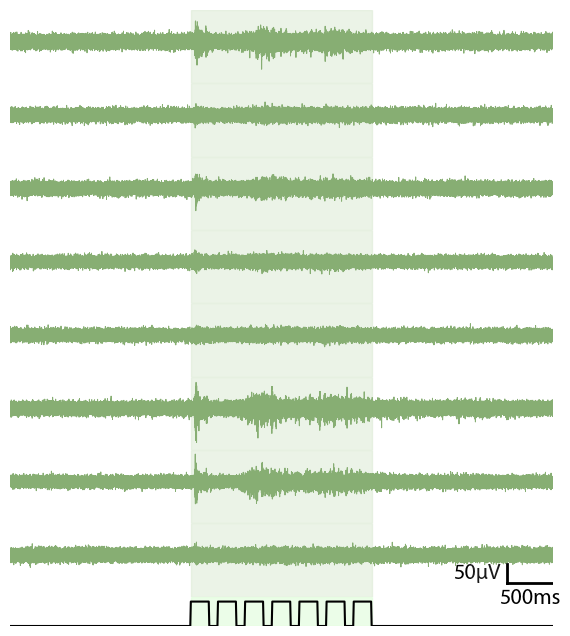

In [ ]:
# Charger les données du fichier brut
dat_file = dat_file_path  # Chemin vers votre fichier .dat
data = np.fromfile(dat_file, dtype=np.float32)  # Charger les données brutes

channel_map = np.load(gui_fold + "/channel_map.npy").reshape(-1, 8)
print("Mapping de l'électrode:", channel_map)

n_shanks, channels_per_shank = channel_map.shape  # Dimensions du mapping
n_channels = n_shanks * channels_per_shank  # Nombre total de canaux

assert data.size % n_channels == 0, "Le nombre de canaux ne correspond pas aux données chargées."

# Paramètres
sampling_rate = 30000  # Fréquence d'échantillonnage

# Reshape des données
data_reshaped = data.reshape((-1, n_channels))

# Réorganiser les canaux selon le mapping
mapped_indices = channel_map.flatten()
data_mapped = data_reshaped[:, mapped_indices]

# Sélection d'un shank spécifique
shank_id = 0  
shank_channels = channel_map[shank_id]  
data_shank = data_mapped[:, shank_channels]

id_stim = 5

for i in range(n_stims):
    # Calcul des bornes pour chaque période en fonction du stimulus
    stim_start = t_stim_start[id_stim]
    stim_end = stim_start + 2
    # stim_end = t_stim_end [0]

# Définir la période d'affichage
stim_duration = stim_end - stim_start

start_time = stim_start - stim_duration
end_time = stim_end + stim_duration

start_sample = int(start_time * sampling_rate)
end_sample = int(end_time * sampling_rate)

# Extraire les données pour cette plage
data_to_plot = data_shank[start_sample:end_sample, :]
time = np.arange(start_sample, end_sample) / sampling_rate  

# Inverser l'ordre pour affichage correct
shank_channels_reversed = shank_channels[::-1]  
data_to_plot_reversed = data_to_plot[:, ::-1]  

# Calculer les limites de l'axe Y
y_max_tac = np.max(data_to_plot_reversed)
y_min_tac = np.min(data_to_plot_reversed)

y_max_rounded = np.ceil(y_max_tac / 10) * 10
y_min_rounded = np.floor(y_min_tac / 10) * 10

print(f"min : {y_min_tac}, max : {y_max_tac}")
print(f"Valeur minimale arrondie: {y_min_rounded}, Valeur maximale arrondie: {y_max_rounded}")


# === Création des subplots ===
fig, axs = plt.subplots(nrows=channels_per_shank + 1, ncols=1, figsize=(7, 1 * channels_per_shank), gridspec_kw={'height_ratios': [1] * channels_per_shank + [0.4]})

# Tracer les signaux des électrodes
for i in range(channels_per_shank):
    real_channel = shank_channels_reversed[i]  
    axs[i].plot(time, data_to_plot_reversed[:, i], color="#87ae73", linewidth=0.7, alpha=1)
    axs[i].axis('off')
    axs[i].axvspan(stim_start, stim_end, color='#D9E9D1', alpha=0.5, label='Tactile stim', zorder=0)
    axs[i].set_xlim(start_time, end_time)
    # axs[i].set_ylim(y_min_tac, y_max_tac)
    axs[i].set_ylim(-108.42, 82.80)




# === Tracer les pulses tactiles en dernier subplot ===
time_series = np.linspace(start_time, end_time, 1000)
pulse_series = np.zeros_like(time_series)

pulse_width = 0.2  
pulse_gap = 0.1    
num_pulses = 7     

pulse_starts = np.linspace(stim_start, stim_start + (num_pulses - 1) * (pulse_width + pulse_gap), num_pulses)

for pulse_start in pulse_starts:
    pulse_end = pulse_start + pulse_width
    pulse_indices = np.where((time_series >= pulse_start) & (time_series < pulse_end))[0]
    pulse_series[pulse_indices] = 1  

axs[-1].plot(time_series, pulse_series, color='k', linewidth=1.5)
axs[-1].axvspan(stim_start, stim_end, color='#d9fdd2', alpha=0.5, label='Tactile stim', zorder=0)
axs[-1].set_xlim(start_time, end_time)
axs[-1].set_ylim(0, 1.2)
axs[-1].axis('off')


# === boîte de légende en bas à droite du dernier subplot ===
# Choisir le subplot 7 (indice 6, car les indices commencent à 0)
shank_id = 7  # On veut placer la boîte dans le subplot 7

# Positionner la boîte en bas à droite du subplot 7
origin_x = end_time - 0.5  # Position en X (temps)
origin_y = y_min_tac + (y_max_tac - y_min_tac) * 0.1  # Position en Y (amplitude)

# Ajouter une boîte blanche pour améliorer la visibilité
legend_box = patches.FancyBboxPatch((origin_x - 0.2, origin_y - 10), 1.2, 60, 
                                    boxstyle="round,pad=0.2", edgecolor='white', 
                                    facecolor='white', alpha=0.1, lw=0.5, zorder=10)
axs[shank_id].add_patch(legend_box)  # Ajouter la boîte de légende dans le subplot 7

# Ajouter l’échelle de temps (barre horizontale)
time_x_end = origin_x + 0.5  # Longueur = 1 seconde
axs[shank_id].plot([origin_x, time_x_end], [origin_y, origin_y], color='black', linewidth=2, zorder=11)
axs[shank_id].text((origin_x + time_x_end) / 2, origin_y - 17, "500ms", fontsize=16, ha='center', va='top')

# Ajouter l’échelle d’amplitude (barre verticale)
amp_y_end = origin_y + 50  # Hauteur = 50 µV
axs[shank_id].plot([origin_x, origin_x], [origin_y, amp_y_end], color='black', linewidth=2, zorder=11)
axs[shank_id].text(origin_x - 0.6, (origin_y + amp_y_end) / 2, "50µV", fontsize=16, ha='left', va='center')

# Ajuster l'espacement des subplots sans les décaler
fig.subplots_adjust(hspace=0.001)

# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, '3B_ML2_tac_cont_raw_traces.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, '3B_ML2_tac_cont_raw_traces.svg'), format='svg', dpi=300)

plt.show()

#

### Fig 3.Bbis - Exemple of ML2 LFP rec for tactile stim (one shank)

In [4]:
# Data file path
data_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus"
sel_folder = "2024.02.29"
sel_rec = 'allego_00__uid0229-13-40-12'

full_folder = os.path.join(data_path, sel_folder, sel_rec)
print (f'path for full folder : {full_folder}')

if os.path.exists(full_folder):
    print(f"Le dossier existe: {full_folder}")
else:
    print(f"Le dossier n'existe pas: {full_folder}")


# .dat file Path
dat_file = sel_rec + '_spy.dat'
# print(dat_file)

dat_file_path = os.path.join (full_folder,dat_file)
print (f'\npath for .dat : {dat_file_path}')


# Zarr and lfp data path
zarr_path = 'U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Analysis_stef'
zarr_folder = sel_folder
zarr_file = sel_rec 
# zarr_file = sel_rec + '_spy'
zarr_folder_path = os.path.join(zarr_path, zarr_folder, zarr_file)

    # Vérification que le chemin est correct
print(f"\nzarr file path : {zarr_folder_path}")

    # Ouvrir les fichiers zarr
raw_data = zarr.open(os.path.join(zarr_folder_path, 'raw', 'dataset.zarr'), mode="r")
ephys_res = zarr.open(os.path.join(zarr_folder_path, 'processed', 'ephys.zarr'), mode="r")

# Affichage de quelques informations sur les datasets
print(f"Contenu de raw_data : {list(raw_data.keys())}")
print(f"Contenu de ephys_res : {list(ephys_res.keys())}")


# Circus sorting path
sorting_fold = os.path.join(full_folder, sel_rec +'_spy')
sorting_path = Path(sorting_fold)
print (f'\npath for circus sorting : {sorting_path}')

gui_fold = os.path.join(sorting_fold, sel_rec + '_spy.GUI')
gui_path = Path(gui_fold)
print (f'\npath for circus-GUI : {gui_fold}')


# cluster_info.tsv file path
clusinfo_path = os.path.join(gui_fold, 'cluster_info.tsv')

# Vérifier si le fichier existe avant de tenter de le lire
if os.path.exists(clusinfo_path):
    print ('')
    clusinfo_df = pd.read_csv(clusinfo_path, sep='\t')  # Fichier tabulé
else:
    raise FileNotFoundError(f"Fichier introuvable : {clusinfo_path}")


path for full folder : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus\2024.02.29\allego_00__uid0229-13-40-12
Le dossier existe: U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus\2024.02.29\allego_00__uid0229-13-40-12

path for .dat : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus\2024.02.29\allego_00__uid0229-13-40-12\allego_00__uid0229-13-40-12_spy.dat

zarr file path : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Analysis_stef\2024.02.29\allego_00__uid0229-13-40-12
Contenu de raw_data : ['adcs', 'channels']
Contenu de ephys_res : ['down_fact', 'lfps', 'sample_rate']

path for circus sorting : U:\PhD\Experimentation\Electrophysiology\S1_recordings_Analysis\Converter_circus\2024.02.29\allego_00__uid0229-13-40-12\allego_00__uid0229-13-40-12_spy

path for circus-GUI : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus\2024.02.29\allego_00__ui

In [5]:
####### Mapping #######
mapping = np.load(gui_fold + "/channel_map.npy").reshape(-1, 8)

####### LFPs + ADCs from zarr #######
lfps = ephys_res["lfps/channels/1"][:]
lfps -= np.median(lfps, axis=0)
adcs = ephys_res["lfps/adcs/1"][:]
stim_present = (adcs[0,:] > 1).astype(int)
t_lfps = ephys_res["lfps/timestamps/1"][:]
srate_acq = (t_lfps.size - 1) / (t_lfps[-1] - t_lfps[0])
np.sum(adcs[0,:]>3.) > t_lfps.size/2

####### Sampling rate for acquisition #######
f_sample_raw = 30000.0

####### Création du dataset pour spiketimes et amplitudes #######
dataset = {}
merged = list(sorting_path.glob("*.result.hdf5"))
if len(merged) != 1:
    logging.warning("Several or none .result.hdf5 file detected. Aborting!")
else:
    with h5py.File(merged[0], "r") as spike_in:
        dataset["spiketimes"] = {}
        dataset["amplitudes"] = {}  # Ajout pour les amplitudes

        for temp in spike_in["spiketimes"].items():
            # Extraction des données de spiketimes
            spiketimes_data = temp[1][:] / f_sample_raw
            dataset["spiketimes"][temp[0]] = spiketimes_data

            # Vérification de la présence d'amplitudes
            if "amplitudes" in spike_in:
                amplitudes_data = spike_in["amplitudes"][temp[0]][:]
                dataset["amplitudes"][temp[0]] = amplitudes_data
            else:
                logging.warning(f"No amplitudes found for {temp[0]}")


####### Selection des neurones valides #######
# Filtrer les neurones valides
valid_df = clusinfo_df.loc[clusinfo_df['group'].isin(['good', 'mua'])]

# Liste des neurones valides (pas les index, mais les valeurs)
valid_all = valid_df['cluster_id'].tolist()

# Récupérer les neurones valides par shank
n_shanks = 4
valid_per_sh = {}
for i_sh in range(n_shanks):
    valid_inds = valid_df.loc[valid_df['sh'] == float(i_sh), 'cluster_id'].tolist()
    valid_per_sh[f'sh#{i_sh}'] = valid_inds

valid_keys = [f'temp_{i}' for i in valid_all]


####### Here we infer the temperature timecourse #######
if TYPE_CHECKING:
    # Type annotations
    Abool = npt.NDArray[np.bool_]
    Afloat = npt.NDArray[np.float64]
    Aint = npt.NDArray[np.int_]


def infer_stim_times(stim_signal, tstamp, th_dur=15.0):

    """Infer stimulus start/stop times from the stimulus signal ttl.

    Args:
        stim_signal (Afloat): stimulus signal ttl .
        t_lfps (Afloat): tstemp of the lfp.
        th_dur (float): duration threshold (in seconds) to infer valid times

    Returns:
        tuple(Afloat): stimulus start times, stimulus end times.

    """
    tactile = True
    if tactile:
        ind_start = 0
    else:
        ind_start = 1 
    up_inds = np.where(np.diff(stim_signal) > 0.5)[0][ind_start:] # stim signal goes up, excluding recording start
    down_inds = np.where(np.diff(stim_signal) < -0.5)[0][ind_start:] # stim signal goes down, excluding recording start

    t_up = tstamp[up_inds]
    t_down = tstamp[down_inds]
    
    valid_up = np.diff(t_up) > th_dur # this is 15. seconds 
    valid_up = np.concatenate(([True], valid_up)) # the first up is always valid
    
    valid_down = np.diff(t_down) > th_dur
    valid_down = np.concatenate((valid_down, [True])) # the last down is always valid
        
    t_stim_start = t_up[valid_up]
    t_stim_end = t_down[valid_down]

    return t_stim_start, t_stim_end

valid_temp_profile = np.max(adcs[0,:]) > 2.0

if valid_temp_profile:
    therm_stim = 10. * adcs[0,:]

t_stim_start, t_stim_end = infer_stim_times(stim_signal=stim_present,tstamp=t_lfps)

n_stims = t_stim_start.size

#time of each pulse end
pulse_end = t_lfps[np.where(np.diff(stim_present) == -1)[0]]
#time of each pulse start
pulse_start = t_lfps[np.where(np.diff(stim_present) == 1)[0]]
#duration of one pulse
pulse_duration = pulse_end - pulse_start
pulse_duration*1000 #print en ms

array([158., 158., 158., 158., 158., 158., 159., 158., 158., 158., 158.,
       158., 158., 158., 158., 158., 158., 158., 158., 158., 158., 158.,
       158., 158., 159., 158., 158., 158., 158., 158., 160., 158., 158.,
       158., 158., 158., 160., 158., 158., 158., 158., 158., 160., 158.,
       158., 158., 158., 158.])

Mapping de l'électrode: [[11  4  8 13 10  6  9 12]
 [14  1  2  3 15  5  0  7]
 [30 22 28 29 26 27 24 31]
 [25 16 20 18 23 17 19 21]]
min : -502.7348505321466, max : 147.17902265320467
Valeur minimale arrondie: -510.0, Valeur maximale arrondie: 150.0


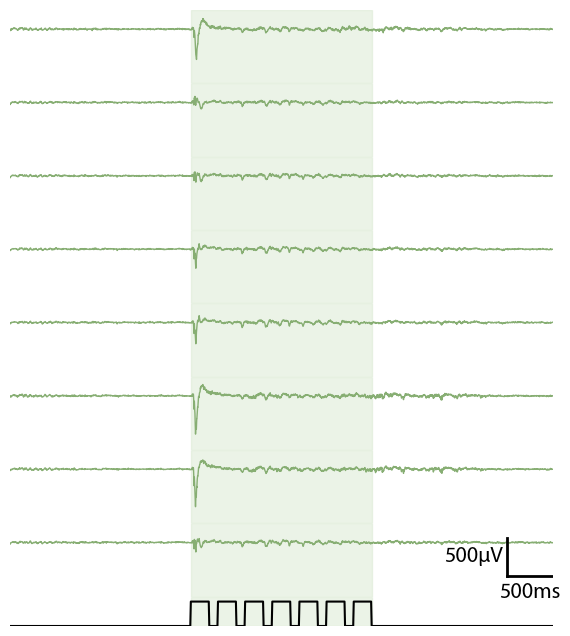

In [6]:
# Charger les données du fichier brut
dat_file = dat_file_path  # Chemin vers votre fichier .dat
data = np.fromfile(dat_file, dtype=np.float32)  # Charger les données brutes

channel_map = np.load(gui_fold + "/channel_map.npy").reshape(-1, 8)
print("Mapping de l'électrode:", channel_map)

n_shanks, channels_per_shank = channel_map.shape  # Dimensions du mapping
n_channels = n_shanks * channels_per_shank  # Nombre total de canaux

assert data.size % n_channels == 0, "Le nombre de canaux ne correspond pas aux données chargées."

# Paramètres
sampling_rate = 30000  # Fréquence d'échantillonnage

# Reshape des données
data_reshaped = data.reshape((-1, n_channels))

# Réorganiser les canaux selon le mapping
mapped_indices = channel_map.flatten()
data_mapped = data_reshaped[:, mapped_indices]

# Sélection d'un shank spécifique
shank_id = 0  
shank_channels = channel_map[shank_id]  
data_shank = data_mapped[:, shank_channels]  

for i in range(n_stims):
    # Calcul des bornes pour chaque période en fonction du stimulus
    stim_start = t_stim_start[2]
    stim_end = stim_start + 2
    # stim_end = t_stim_end [0]

# Définir la période d'affichage
stim_duration = stim_end - stim_start

start_time = stim_start - stim_duration
end_time = stim_end + stim_duration

start_sample = int(start_time * sampling_rate)
end_sample = int(end_time * sampling_rate)

# Extraire les données pour cette plage
data_to_plot = data_shank[start_sample:end_sample, :]
time = np.arange(start_sample, end_sample) / sampling_rate  

# Inverser l'ordre pour affichage correct
shank_channels_reversed = shank_channels[::-1]  
data_to_plot_reversed = data_to_plot[:, ::-1]  

# Fonction pour appliquer un filtre passe-bas
def lowpass_filter(data, cutoff=200, fs=30000, order=4):
    nyquist = 0.5 * fs  # Fréquence de Nyquist
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data, axis=0)

# Appliquer le filtrage passe-bas Butterworth
data_filtered = lowpass_filter(data_to_plot_reversed)

# Appliquer le filtre Savitzky-Golay (fenêtre = 101, polynôme = 3)
data_filtered_savgol = savgol_filter(data_filtered, window_length=101, polyorder=3, axis=0)


# Calculer les limites de l'axe Y
y_max_tac = np.max(data_filtered_savgol)
y_min_tac = np.min(data_filtered_savgol)

y_max_rounded = np.ceil(y_max_tac / 10) * 10
y_min_rounded = np.floor(y_min_tac / 10) * 10

print(f"min : {y_min_tac}, max : {y_max_tac}")
print(f"Valeur minimale arrondie: {y_min_rounded}, Valeur maximale arrondie: {y_max_rounded}")


# === Création des subplots ===
fig, axs = plt.subplots(nrows=channels_per_shank + 1, ncols=1, figsize=(7, 1 * channels_per_shank), gridspec_kw={'height_ratios': [1] * channels_per_shank + [0.4]})

# Tracer les signaux des électrodes
for i in range(channels_per_shank):
    real_channel = shank_channels_reversed[i]  
    axs[i].plot(time, data_filtered_savgol[:, i], color="#87ae73", linewidth=1)
    axs[i].axis('off')
    axs[i].axvspan(stim_start, stim_end, color='#D9E9D1', alpha=0.5, label='Tactile stim', zorder=0)
    axs[i].set_xlim(start_time, end_time)
    axs[i].set_ylim(-710, 250)    



# === Tracer les pulses tactiles en dernier subplot ===
time_series = np.linspace(start_time, end_time, 1000)
pulse_series = np.zeros_like(time_series)

pulse_width = 0.2  
pulse_gap = 0.1    
num_pulses = 7     

pulse_starts = np.linspace(stim_start, stim_start + (num_pulses - 1) * (pulse_width + pulse_gap), num_pulses)

for pulse_start in pulse_starts:
    pulse_end = pulse_start + pulse_width
    pulse_indices = np.where((time_series >= pulse_start) & (time_series < pulse_end))[0]
    pulse_series[pulse_indices] = 1  

axs[-1].plot(time_series, pulse_series, color='k', linewidth=1.5)
axs[-1].axvspan(stim_start, stim_end, color='#D9E9D1', alpha=0.5, label='Tactile stim', zorder=0)
axs[-1].set_xlim(start_time, end_time)
axs[-1].set_ylim(0, 1.2)
axs[-1].axis('off')


# === boîte de légende en bas à droite du dernier subplot ===
# Choisir le subplot 7 (indice 6, car les indices commencent à 0)
shank_id = 7  # On veut placer la boîte dans le subplot 7

# Positionner la boîte en bas à droite du subplot 7
origin_x = end_time - 0.5  # Position en X (temps)
origin_y = y_min_tac + (y_max_tac - y_min_tac) * 0.1  # Position en Y (amplitude)

# Ajouter une boîte blanche pour améliorer la visibilité
legend_box = patches.FancyBboxPatch((origin_x - 0.2, origin_y - 10), 1.2, 60, 
                                    boxstyle="round,pad=0.2", edgecolor='white', 
                                    facecolor='white', alpha=0.1, lw=0.5, zorder=10)
axs[shank_id].add_patch(legend_box)  # Ajouter la boîte de légende dans le subplot 7

# Ajouter l’échelle de temps (barre horizontale)
time_x_end = origin_x + 0.5  # Longueur = 1 seconde
axs[shank_id].plot([origin_x, time_x_end], [origin_y, origin_y], color='black', linewidth=2, zorder=11)
axs[shank_id].text((origin_x + time_x_end) / 2, origin_y - 100, "500ms", fontsize=16, ha='center', va='top')

# Ajouter l’échelle d’amplitude (barre verticale)
amp_y_end = origin_y + 500  # Hauteur = 50 µV
axs[shank_id].plot([origin_x, origin_x], [origin_y, amp_y_end], color='black', linewidth=2, zorder=11)
axs[shank_id].text(origin_x - 0.7, (origin_y + amp_y_end) / 2, "500µV", fontsize=16, ha='left', va='center')

# Ajuster l'espacement des subplots sans les décaler
fig.subplots_adjust(hspace=0.001)

# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, '3Bbis_ML2_tac_cont_raw_traces.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, '3Bbis_ML2_tac_cont_raw_traces.svg'), format='svg', dpi=300)

plt.show()

#

### Fig 3.C - Exemple raster for ML2 tactile stim one neuron (8 stim)

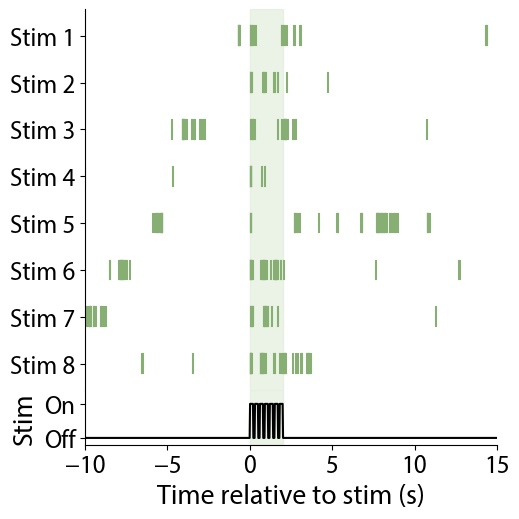

valid_key[4]: temp_5


In [ ]:
# Paramètres
time_before_stim = 10  # 10 secondes avant le début du stimulus
time_after_stim = 15   # 15 secondes après le début du stimulus

# Sélectionner un valid_key
valid_key = valid_keys[22]  # Choisir un seul neurone / 10, 15, 21, 22

# Récupérer les spikes pour ce neurone spécifique
spikes = dataset['spiketimes'][valid_key]

# === Création des subplots ===
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 5), sharex=True, gridspec_kw={'height_ratios': [7, 1]})

# Tracer les spikes pour chaque stimulus
for i in range(len(t_stim_start)):  # Pour chaque stimulus (de 1 à 8)
    stim_start = t_stim_start[i]
    stim_end = t_stim_end[i]

    # Définir la fenêtre d'intérêt autour du stimulus (10 secondes avant et après)
    window_start = stim_start - time_before_stim
    window_end = stim_end + time_after_stim

    # Sélectionner les spikes dans cette fenêtre et les aligner par rapport au début du stimulus
    selected_spikes = [spike - stim_start for spike in spikes if window_start <= spike <= window_end]

    # Tracer les spikes alignés pour ce stimulus
    for spike in selected_spikes:
        ax1.plot([spike, spike], [i + 0.2, i - 0.2], color='#87ae73')  # Ligne verticale pour chaque spike

# Paramétrage du raster plot
ax1.set_ylabel('')  # Label de l'axe Y

# Inverser l'ordre des ticks de l'axe Y et l'axe Y
ax1.set_yticks(range(len(t_stim_start)-1, -1, -1))  # Inverser l'ordre des ticks
ax1.set_yticklabels([f'Stim {i+1}' for i in range(len(t_stim_start)-1, -1, -1)])  # Labels des stimuli inversés

# Limiter l'axe des x pour afficher la fenêtre autour du stimulus
ax1.set_xlim([-time_before_stim, time_after_stim])  # Afficher de -10s à +15s autour de chaque stimulus

# Inverser l'axe Y pour avoir Stim 1 en haut et Stim 8 en bas
ax1.invert_yaxis()  # Inverse l'axe Y

ax1.axvspan(0, 2, color='#D9E9D1', alpha=0.5, label='Tactile stim', zorder=0)

# Suppression des bordures superflues
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(False)
ax1.xaxis.set_visible(False)


# === Tracer les pulses tactiles en dernier subplot ===
time_series = np.linspace(-time_before_stim, time_after_stim, 1000)
pulse_series = np.zeros_like(time_series)

pulse_width = 0.2  # Durée de chaque pulsation
pulse_gap = 0.1    # Ecart entre chaque pulsation
num_pulses = 7     # Nombre de pulsations

# Placer les pulsations pour chaque stimulus
for i in range(len(t_stim_start)):  # Pour chaque stimulus
    stim_start = t_stim_start[i]

    # Calculer le temps de début des pulsations dans la fenêtre [0, 2s]
    pulse_starts = np.linspace(0, 2 - pulse_width, num_pulses)  # Les pulsations commencent à 0 et s'étendent sur 2 secondes

    # Ajouter chaque pulsation
    for pulse_start in pulse_starts:
        pulse_end = pulse_start + pulse_width

        # Ajouter les indices des pulsations dans la série de temps
        pulse_indices = np.where((time_series >= pulse_start) & (time_series < pulse_end))[0]
        pulse_series[pulse_indices] = 1

# Tracer les impulsions tactiles dans le second subplot
ax2.plot(time_series, pulse_series, color='k', linewidth=1.5)

ax2.axvspan(0, 2, color='#D9E9D1', alpha=0.5, label='Tactile stim', zorder=0)

ax2.set_xlim(-time_before_stim, time_after_stim)
ax2.set_xlabel('Time relative to stim (s)')
ax2.set_ylabel('Stim')
ax2.set_yticks([0, 1])
ax2.set_ylim(-0.2, 1.4)  # Ajuster pour rendre les pulses visibles
ax2.set_yticklabels(['Off', 'On'])


# Suppression des bordures superflues
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Ajustements finaux
plt.tight_layout(pad=0.001, h_pad=0.001)

# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, '3C_ML2_tac_cont_raster.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, '3C_ML2_tac_cont_raster.svg'), format='svg', dpi=300)

plt.show()

print(f'valid_key[4]: {valid_keys[4]}')



#

### Fig 3.D - ML2 Tactile response rate contra vs ipsi

n (Cont) = 5
n (Ipsi) = 5
Wilcoxon test result: statistic = 0.0000, p-value = 0.0625


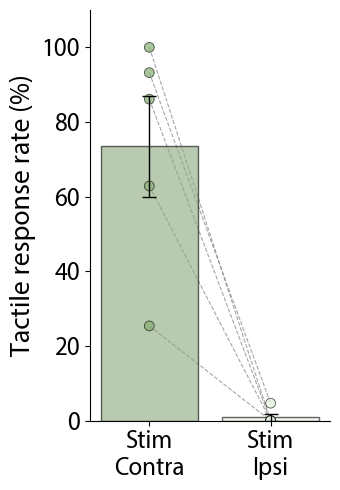


WT_tac_cont : mean = 73.51 ± 13.56
WT_tac_ipsi : mean = 0.94 ± 0.94

contra: n_cluster : 237
ipsi: n_cluster : 123


In [ ]:
# Charger les fichiers
WT_tac_cont_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/cluster_response_rate/Tac_Wcont_ML2_resp_rate.xlsx"
df_WT_tac_cont = pd.read_excel(WT_tac_cont_path)

WT_tac_ipsi_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/cluster_response_rate/Tac_Wipsi_ML2_resp_rate.xlsx"
df_WT_tac_ipsi = pd.read_excel(WT_tac_ipsi_path)

# Calcul du pourcentage de '1' dans la colonne 'response' pour chaque combinaison de 'directory' et 'file_name'
def calculate_response_percentage(df):
    # Grouper par 'directory' et 'file_name' et calculer le pourcentage de 1 dans la colonne 'response'
    response_percentage = df.groupby(['directory', 'file_name'])['response'].agg(
        lambda x: (x.sum() / len(x)) * 100
    ).reset_index()
    
    # Renommer la colonne pour plus de clarté
    response_percentage.rename(columns={'response': 'response_percentage'}, inplace=True)
    
    return response_percentage

# Appliquer la fonction sur chaque DataFrame
response_percentage_WT_tac_cont = calculate_response_percentage(df_WT_tac_cont)
response_percentage_WT_tac_ipsi = calculate_response_percentage(df_WT_tac_ipsi)

# Extraire les 'directory' présents dans les deux DataFrames
directories_cont = response_percentage_WT_tac_cont['directory']
directories_ipsi = response_percentage_WT_tac_ipsi['directory']

# Trouver les 'directory' communs aux deux DataFrames
common_directories = set(directories_cont).intersection(set(directories_ipsi))

# Filtrer les DataFrames pour ne conserver que les 'directory' communs
filtered_cont = response_percentage_WT_tac_cont[response_percentage_WT_tac_cont['directory'].isin(common_directories)]
filtered_ipsi = response_percentage_WT_tac_ipsi[response_percentage_WT_tac_ipsi['directory'].isin(common_directories)]

# Calculer la moyenne des pourcentages de réponse pour chaque 'directory' commun
average_response_percentage_cont = filtered_cont.groupby('directory')['response_percentage'].mean().reset_index()
average_response_percentage_ipsi = filtered_ipsi.groupby('directory')['response_percentage'].mean().reset_index()

# Créer une nouvelle colonne 'group' pour identifier chaque DataFrame
average_response_percentage_cont['group'] = 'Cont'
average_response_percentage_ipsi['group'] = 'Ipsi'

# Fusionner les deux DataFrames en un seul
combined_df = pd.concat([average_response_percentage_cont, average_response_percentage_ipsi])

# Calculer la SEM pour chaque groupe
combined_df['sem'] = combined_df.groupby('group')['response_percentage'].transform(sem)

# Calculer n (le nombre d'observations pour chaque groupe)
n_cont = len(average_response_percentage_cont)
n_ipsi = len(average_response_percentage_ipsi)

# Effectuer le test de Wilcoxon pour comparer les groupes 'Cont' et 'Ipsi'
stat, p_value = wilcoxon(average_response_percentage_cont['response_percentage'], 
                         average_response_percentage_ipsi['response_percentage'])

# Afficher les résultats avec n et p-value
print(f"n (Cont) = {n_cont}")
print(f"n (Ipsi) = {n_ipsi}")
print(f"Wilcoxon test result: statistic = {stat:.4f}, p-value = {p_value:.4f}")


# Couleurs
# colors = {'Cont': '#2a7e19', 'Ipsi': '#A8E5A0'}
colors = {'Cont': '#87ae73', 'Ipsi': '#e2f0dc'}


border_colors = 'k'

# Plot
plt.figure(figsize=(3.5, 5))

# Créer un barplot par groupe (moyenne des response_percentage par group) avec des couleurs personnalisées
sns.barplot(x='group', y='response_percentage', data=combined_df, 
            errorbar=None,  # Désactive les barres d'erreur
            hue='group', palette=colors, capsize=0.1, err_kws={'linewidth': 1}, alpha=0.6, edgecolor=border_colors)

# Ajouter des points de scatter pour chaque directory avec des couleurs personnalisées pour chaque groupe
sns.scatterplot(x='group', y='response_percentage', hue='group', data=combined_df, 
                palette=colors, s=50, legend=None, marker='o', edgecolor=border_colors, alpha=0.7)

# Ajouter les lignes de connexion entre les points de 'Cont' et 'Ipsi' pour chaque 'directory'
for directory in common_directories:
    cont_value = average_response_percentage_cont[average_response_percentage_cont['directory'] == directory]['response_percentage'].values[0]
    ipsi_value = average_response_percentage_ipsi[average_response_percentage_ipsi['directory'] == directory]['response_percentage'].values[0]
    
    # Tracer une ligne entre les points 'Cont' et 'Ipsi' pour le même 'directory'
    plt.plot(['Cont', 'Ipsi'], [cont_value, ipsi_value], color='grey', linestyle='--', linewidth=0.8, alpha=0.7, zorder=0)

# Ajouter les barres d'erreur (SEM)
for i, group in enumerate(combined_df['group'].unique()):
    group_data = combined_df[combined_df['group'] == group]
    plt.errorbar(x=[i], y=group_data['response_percentage'].mean(), yerr=group_data['sem'].mean(),
                 fmt='none', color=border_colors, capsize=5, elinewidth=1)


# Fonction pour ajouter une barre de significativité
def add_Wilcox_sig_bar(x1, x2, y, p_val, height_offset=1.2, fontsize=18):
    if p_val < 0.001:
        significance = "***"
    elif p_val < 0.01:
        significance = "**"
    elif p_val < 0.05:
        significance = "*"
    else:
        return

    plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
    plt.text((x1 + x2) * 0.5, y , significance, ha='center', va='bottom', color='black', fontsize=fontsize)

# Ajouter la barre de significativité si p < 0.05
y_max = max(combined_df['response_percentage']) + 0.02  # Ajustement vertical
if p_value < 0.05:
    add_Wilcox_sig_bar(0, 1, y_max + 3, p_value)


# Ajouter le titre et les labels
plt.xlabel('')
plt.ylabel('Tactile response rate (%)')
xtick_labels = ['Stim\nContra', 'Stim\nIpsi']  # Les nouveaux labels pour les xticks
plt.xticks(ticks=[0, 1], labels=xtick_labels)
plt.ylim(0, 110)


# Suppression des bordures superflues
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Afficher le graphique
plt.tight_layout()

# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, '3D_ML2_tac_cont_ipsi_resp_rate.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, '3D_ML2_tac_cont_ipsi_resp_rate.svg'), format='svg', dpi=300)

plt.show()


############################    Metrics   ############################ 

# Calculer la moyenne et SEM pour 'WT_tac_cont'
mean_cont = average_response_percentage_cont['response_percentage'].mean()
sem_cont = sem(average_response_percentage_cont['response_percentage'])

# Calculer la moyenne et SEM pour 'WT_tac_ipsi'
mean_ipsi = average_response_percentage_ipsi['response_percentage'].mean()
sem_ipsi = sem(average_response_percentage_ipsi['response_percentage'])

# Afficher les résultats
print(f"\nWT_tac_cont : mean = {mean_cont:.2f} ± {sem_cont:.2f}")
print(f"WT_tac_ipsi : mean = {mean_ipsi:.2f} ± {sem_ipsi:.2f}")


# Calculer nombre cluster par conditions
n_cluster_tac_cont = len(df_WT_tac_cont)
n_cluster_tac_ipsi = len(df_WT_tac_ipsi)

print(f"\ncontra: n_cluster : {n_cluster_tac_cont}")
print(f"ipsi: n_cluster : {n_cluster_tac_ipsi}")

### Fig 3.D_BIS - Cluster/Contingence - ML2 Tactile response rate contra vs ipsi

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



Table de contingence (nombre d'occurences de 0 et 1 par groupe) :
response    0    1
Tac_Cont   88  149
Tac_Ipsi  120    3

Test chi2 de contingence entre groupes : chi2 = 118.751, p = 1.188e-27, dof = 1
=> Différence significative entre groupes

Tests post-hoc (test exact de Fisher) avec correction de Bonferroni :
Tac_Cont vs Tac_Ipsi : p = 1.201e-33, p corrigé = 1.201e-33 -> SIGNIFICATIF


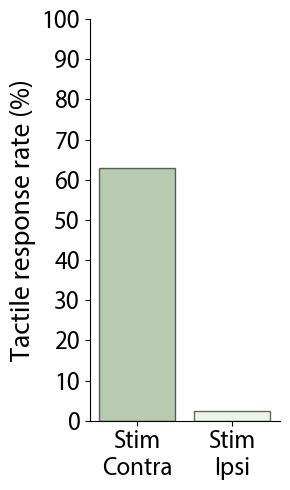


Métriques des réponses par groupe :
Tac_Cont : Moyenne = 0.63, Nombre de clusters = 237, Pourcentage de réponse = 62.9%
Tac_Ipsi : Moyenne = 0.02, Nombre de clusters = 123, Pourcentage de réponse = 2.4%


In [4]:
# Chemins fichiers
file_paths = {
    "Tac_Cont": "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/cluster_response_rate/Tac_Wcont_ML2_resp_rate.xlsx",
    "Tac_Ipsi": "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/cluster_response_rate/Tac_Wipsi_ML2_resp_rate.xlsx"
}


# Chargement des données
dfs = {}
for key, path in file_paths.items():
    if os.path.exists(path):
        dfs[key] = pd.read_excel(path)
    else:
        print(f"⚠️ Fichier non trouvé : {path}")


# Calcul pourcentages réponse/non-réponse
group_counts = {}
for key, df in dfs.items():
    counts = df['response'].value_counts(normalize=True) * 100
    group_counts[key] = {
        'No Response (0)': counts.get(0, 0),
        'Response (1)': counts.get(1, 0)
    }


# DataFrame pour plot
contingency_df = pd.DataFrame(group_counts).T.reset_index().rename(columns={'index': 'group'})
contingency_melted = contingency_df.melt(id_vars='group', var_name='Response Type', value_name='Percentage')
contingency_melted_response_only = contingency_melted[contingency_melted['Response Type'] == 'Response (1)']


# Couleurs personnalisées
response_colors = {
    'Tac_Cont': '#87ae73',
    'Tac_Ipsi': '#e2f0dc'
}

border_colors = 'k'

# Plot barplot
plt.figure(figsize=(3, 5))
ax = sns.barplot(
    data=contingency_melted_response_only,
    x='group', y='Percentage', hue='group',
    palette=response_colors,
    edgecolor=border_colors,
    alpha=0.6, errorbar=None
)

# Table de contingence brute
contingency_table = pd.DataFrame({
    key: dfs[key]['response'].value_counts() for key in dfs.keys()
}).fillna(0).astype(int).T

print("\nTable de contingence (nombre d'occurences de 0 et 1 par groupe) :")
print(contingency_table)

# Test global chi2
chi2, p, dof, expected = chi2_contingency(contingency_table.values)
print(f"\nTest chi2 de contingence entre groupes : chi2 = {chi2:.3f}, p = {p:.4g}, dof = {dof}")
if p < 0.05:
    print("=> Différence significative entre groupes")
else:
    print("=> Pas de différence significative entre groupes")

# Tests post-hoc (Fisher exact test)
groups = contingency_table.index.tolist()
results = []

for g1, g2 in combinations(groups, 2):
    table = contingency_table.loc[[g1, g2], [0, 1]].values
    oddsratio, pvalue = fisher_exact(table)
    results.append({'Group1': g1, 'Group2': g2, 'pvalue': pvalue})

# Correction Bonferroni
num_tests = len(results)
for res in results:
    res['pvalue_corrected'] = min(res['pvalue'] * num_tests, 1.0)

print("\nTests post-hoc (test exact de Fisher) avec correction de Bonferroni :")
for res in results:
    signif = "SIGNIFICATIF" if res['pvalue_corrected'] < 0.05 else "non significatif"
    print(f"{res['Group1']} vs {res['Group2']} : p = {res['pvalue']:.4g}, p corrigé = {res['pvalue_corrected']:.4g} -> {signif}")


# # Annoter les significativités sur le plot
# def add_contingence_sig_bar(ax, x1, x2, y, p_val, height_offset=1, fontsize=18):
#     significance = ""
#     if p_val < 0.001:
#         significance = "***"
#     elif p_val < 0.01:
#         significance = "**"
#     elif p_val < 0.05:
#         significance = "*"
#     if significance:
#         ax.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
#         ax.text((x1 + x2) * 0.5, y - 0.05 , significance,
#                 ha='center', va='bottom', color='black', fontsize=fontsize)

# positions = {g: i for i, g in enumerate(contingency_df['group'])}
# y_offset = contingency_melted_response_only['Percentage'].max() + 5
# spacing_between_bars = 0.8

# for res in results:
#     if res['pvalue_corrected'] < 0.05:
#         x1 = positions[res['Group1']]
#         x2 = positions[res['Group2']]
#         add_contingence_sig_bar(ax, x1, x2, y_offset, res['pvalue_corrected'])
#         y_offset += spacing_between_bars

# Labels
plt.xlabel('')
plt.ylabel('Tactile response rate (%)')
plt.xticks(ticks=[0, 1], labels=['Stim\nContra', 'Stim\nIpsi'])
plt.yticks(range(0, 101, 10))
plt.ylim(0, 100)

# Suppression bordures inutiles
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.legend().remove()
plt.tight_layout()

# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, '3D_BIS_ML2_tac_cont_ipsi_resp_rate_cluster_contingence.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, '3D_BIS_ML2_tac_cont_ipsi_resp_rate_cluster_contingence.svg'), format='svg', dpi=300)


plt.show()


############################ Metrics ############################

print("\nMétriques des réponses par groupe :")
for key, df in dfs.items():
    mean_response = df['response'].mean()  # moyenne des 0 et 1 = taux de réponse en fraction
    n_clusters = len(df)
    response_percentage = mean_response * 100
    print(f"{key} : Moyenne = {mean_response:.2f}, Nombre de clusters = {n_clusters}, Pourcentage de réponse = {response_percentage:.1f}%")



#

### Fig 3.E - SDF_mean tactile contra ML2

Friedman test results:
          Source     W  ddof1    Q     p-unc
Friedman  period  0.84      2  8.4  0.014996
Effet global de period: Significatif (p-unc = 0.0150)

Post-hoc Dunn test with Bonferroni correction:
           Baseline      Stim  Post_stim
Baseline   1.000000  0.085132   1.000000
Stim       0.085132  1.000000   0.005589
Post_stim  1.000000  0.005589   1.000000


c:\Users\zayan\Anaconda\envs\analysis\lib\site-packages\scikit_posthocs\_posthocs.py:371: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  x_lens = x.groupby(_group_col)[_val_col].count()
c:\Users\zayan\Anaconda\envs\analysis\lib\site-packages\scikit_posthocs\_posthocs.py:374: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  x_ranks_avg = x.groupby(_group_col)["ranks"].mean()


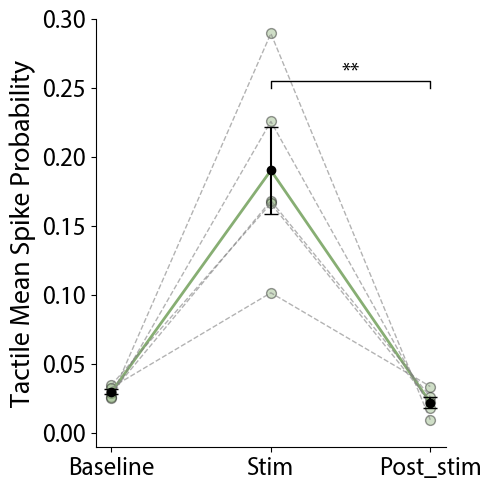

      period  mean_sdf   sem_sdf  N_animal
0   Baseline  0.030025  0.001821         5
1       Stim  0.190425  0.031605         5
2  Post_stim  0.022389  0.004010         5

       period  n_cluster
0   Baseline        237
1  Post_stim        237
2       Stim        237


In [20]:
# Charger le fichier
file_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Tac_Wcont_ML2_grouped.xlsx"
df = pd.read_excel(file_path)

# Définir l'ordre des périodes
period_order = ['Baseline', 'Stim', 'Post_stim']

# Calculer la moyenne de 'sdf' en groupant par 'directory' et 'period'
df_grouped = df.groupby(['directory', 'period'])['sdf'].mean().reset_index()

# Assurez-vous que les périodes sont dans l'ordre souhaité
df_grouped['period'] = pd.Categorical(df_grouped['period'], categories=period_order, ordered=True)

# Trier les données par période
df_grouped = df_grouped.sort_values('period')

# Calculer la moyenne et SEM pour chaque 'period'
mean_sdf = df_grouped.groupby('period', observed=False)['sdf'].mean()
sem_sdf = df_grouped.groupby('period', observed=False)['sdf'].sem()

# Test de Friedman
friedman_results = pg.friedman(data=df_grouped, dv='sdf', within='period', subject='directory')
print("Friedman test results:")
print(friedman_results)

# Vérifier la significativité
effect_significance = "Significatif" if friedman_results['p-unc'].iloc[0] < 0.05 else "Non significatif"
print(f"Effet global de period: {effect_significance} (p-unc = {friedman_results['p-unc'].iloc[0]:.4f})")


# Test de Dunn post-hoc avec correction de Bonferroni
if friedman_results['p-unc'].iloc[0] < 0.05 :
    posthoc_results = sp.posthoc_dunn(df_grouped, val_col='sdf', group_col='period', p_adjust='bonferroni')
    posthoc_results.index = period_order
    posthoc_results.columns = period_order
    print("\nPost-hoc Dunn test with Bonferroni correction:")
    print(posthoc_results)

# Créer le plot
plt.figure(figsize=(5, 5))
colors = '#87ae73' #2a7e19'
border_colors = 'k'

# Ajouter les points individuels
plt.scatter(df_grouped['period'], df_grouped['sdf'], color=colors, edgecolor=border_colors, linewidth=1, alpha=0.4, marker='o', s=50, zorder=1)

# Ajouter les lignes de connexion entre périodes
for directory in df_grouped['directory'].unique():
    subset = df_grouped[df_grouped['directory'] == directory]
    plt.plot(subset['period'], subset['sdf'], color='grey', linestyle='--', alpha=0.6, lw=1)

# Ajouter les points de la moyenne
plt.scatter(mean_sdf.index, mean_sdf.values, color='black', s=20, label='Mean', zorder=10)
plt.errorbar(mean_sdf.index, mean_sdf.values, yerr=sem_sdf.values, fmt='o', color='black', capsize=5, zorder=2)
plt.plot(mean_sdf.index, mean_sdf.values, color=colors, linestyle='-', linewidth=2, zorder=1)

# Ajouter les barres de significativité
def add_sig_bar(x1, x2, y, p_val, height_offset=0.005, fontsize=16):
    significance = ""
    if p_val < 0.001:
        significance = "***"
    elif p_val < 0.01:
        significance = "**"
    elif p_val < 0.05:
        significance = "*"
    
    if significance:
        plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
        plt.text((x1 + x2) * 0.5, y + height_offset, significance, ha='center', va='bottom', color='black', fontsize=fontsize)

positions = {'Baseline': 0, 'Stim': 1, 'Post_stim': 2}
y_offset = 0.25  # Décalage vertical initial
spacing_between_bars = 0.01

if friedman_results['p-unc'].iloc[0] < 0.05 :
    for i, p1 in enumerate(period_order):
        for j, p2 in enumerate(period_order):
            if i < j:
                p_val = posthoc_results.loc[p1, p2]
                if p_val < 0.05:
                    add_sig_bar(positions[p1], positions[p2], y_offset, p_val)
                    y_offset += spacing_between_bars

plt.xlabel("")
plt.ylabel("Tactile Mean Spike Probability")
plt.xticks(ticks=np.arange(len(period_order)), labels=period_order)
plt.ylim(-0.01,0.30)


ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


plt.tight_layout()


# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, '3E_SDF_ML2_tac_contra_period.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, '3E_SDF_ML2_tac_contra_period.svg'), format='svg', dpi=300)

plt.show()


############################    Metrics   ############################ 

summary_table = df_grouped.groupby('period', observed=False).agg(
    mean_sdf=('sdf', 'mean'),
    sem_sdf=('sdf', 'sem'),
    N_animal=('sdf', 'size'),
).reset_index()
print(summary_table)

summary_table2 = df.groupby('period', observed=False).agg(
    n_cluster=('sdf', 'size')
).reset_index()
print("\n", summary_table2)


### Fig 3.E_BIS - Cluster - SDF_mean tactile contra ML2

Period Baseline: p = 0.0685 (Normal)
Period Stim: p = 0.0003 (Non normal)
Period Post_stim: p = 0.0066 (Non normal)

📊 Résultats du test de Friedman :
          Source         W  ddof1           Q         p-unc
Friedman  period  0.653955      2  309.974684  4.896127e-68

Effet global de 'period' : Significatif (p = 0.0000)

🧪 Post-hoc Dunn avec correction Bonferroni :
               Baseline          Stim     Post_stim
Baseline   1.000000e+00  5.547670e-59  4.746148e-03
Stim       5.547670e-59  1.000000e+00  1.545315e-83
Post_stim  4.746148e-03  1.545315e-83  1.000000e+00


c:\Users\zayan\Anaconda\envs\analysis\lib\site-packages\scikit_posthocs\_posthocs.py:371: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  x_lens = x.groupby(_group_col)[_val_col].count()
c:\Users\zayan\Anaconda\envs\analysis\lib\site-packages\scikit_posthocs\_posthocs.py:374: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  x_ranks_avg = x.groupby(_group_col)["ranks"].mean()


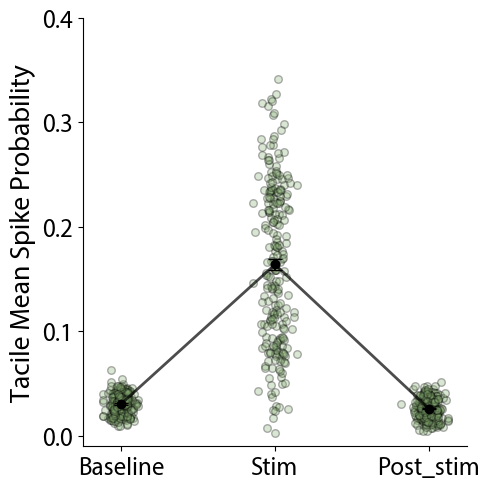


📈 Tableau récapitulatif par période :
      period  mean_sdf   sem_sdf  N_neuron_unique
0   Baseline  0.030574  0.000624              237
1       Stim  0.164064  0.004997              237
2  Post_stim  0.026066  0.000667              237


In [ ]:
#  Charger le fichier Excel
file_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Tac_Wcont_ML2_grouped.xlsx"
df = pd.read_excel(file_path)

# Définir l'ordre des périodes
period_order = ['Baseline', 'Stim', 'Post_stim']
df['period'] = pd.Categorical(df['period'], categories=period_order, ordered=True)

# Regrouper par neurone unique et période pour s'assurer d'une entrée unique
df_unique = df.groupby(['directory', 'file_name', 'neuron_id', 'period'], as_index=False, observed=True).mean(numeric_only=True)

# Calculer la moyenne et SEM globales par période
mean_sem = df_unique.groupby('period', observed=True)['sdf'].agg(['mean', 'sem']).reindex(period_order)

# 1. Nettoyage des données
df_unique_clean = df_unique.dropna(subset=['sdf'])

# 2. Créer une colonne 'subject' pour identifier chaque neurone
df_unique_clean['subject'] = df_unique_clean['directory'] + '_' + df_unique_clean['file_name'] + '_' + df_unique_clean['neuron_id'].astype(str)


for period in df_unique_clean['period'].unique():
    subset = df_unique_clean[df_unique_clean['period'] == period]
    stat, p = shapiro(subset['sdf'])
    print(f"Period {period}: p = {p:.4f} ({'Non normal' if p < 0.05 else 'Normal'})")


# ---------- 📊 TEST DE FRIEDMAN ----------
# # 1. Nettoyage des données
# df_unique_clean = df_unique.dropna(subset=['sdf'])

# # 2. Créer une colonne 'subject' pour identifier chaque neurone
# df_unique_clean['subject'] = df_unique_clean['directory'] + '_' + df_unique_clean['file_name'] + '_' + df_unique_clean['neuron_id'].astype(str)

# 3. S'assurer que les périodes sont bien catégorisées et ordonnées
period_order = ['Baseline', 'Stim', 'Post_stim']
df_unique_clean['period'] = pd.Categorical(df_unique_clean['period'], categories=period_order, ordered=True)

# 4. Garder seulement les sujets ayant des valeurs pour toutes les périodes (Friedman exige mesures répétées complètes)
complete_subjects = df_unique_clean.groupby('subject')['period'].nunique() == len(period_order)
df_friedman_cool_cluster = df_unique_clean[df_unique_clean['subject'].isin(complete_subjects[complete_subjects].index)]

# 5. Appliquer le test de Friedman (format long)
friedman_results_cool_cluster = pg.friedman(data=df_friedman_cool_cluster, dv='sdf', within='period', subject='subject')
print("\n📊 Résultats du test de Friedman :")
print(friedman_results_cool_cluster)

# 6. Vérifier significativité
pval_cool_cluster = friedman_results_cool_cluster['p-unc'].iloc[0]
effect_significance = "Significatif" if pval_cool_cluster < 0.05 else "Non significatif"
print(f"\nEffet global de 'period' : {effect_significance} (p = {pval_cool_cluster:.4f})")

# 7. Si significatif, faire un post-hoc de Dunn
if pval_cool_cluster < 0.05:
    print("\n🧪 Post-hoc Dunn avec correction Bonferroni :")
    posthoc_results_cool_cluster = sp.posthoc_dunn(df_friedman_cool_cluster, val_col='sdf', group_col='period', p_adjust='bonferroni')
    posthoc_results_cool_cluster = posthoc_results_cool_cluster.loc[period_order, period_order]
    print(posthoc_results_cool_cluster)


# Créer le plot
plt.figure(figsize=(5, 5))
colors = '#87ae73'
border_colors = 'k'

# Appliquer un jitter sur l'axe x
x_jitter = df_unique['period'].cat.codes + np.random.normal(0, 0.05, size=len(df_unique))

# Puis plot avec jitter
plt.scatter(x_jitter, df_unique['sdf'],
            color=colors, edgecolor=border_colors,
            linewidth=1, alpha=0.3, marker='o', s=30, zorder=0)

# Ajouter les moyennes ± SEM
plt.errorbar(mean_sem.index, mean_sem['mean'], yerr=mean_sem['sem'],
             fmt='o', color='black', capsize=5, label='Mean ± SEM', zorder=2)
plt.plot(mean_sem.index, mean_sem['mean'],
         color='k', alpha=0.7, linestyle='-', linewidth=2, zorder=1)

# # Ajouter les barres de significativité
# def add_sig_bar(x1, x2, y, p_val, height_offset=0.005, fontsize=18):
#     significance = ""
#     if p_val < 0.001:
#         significance = "***"
#     elif p_val < 0.01:
#         significance = "**"
#     elif p_val < 0.05:
#         significance = "*"
    
#     if significance:
#         plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
#         plt.text((x1 + x2) * 0.5, y - height_offset , significance, ha='center', va='bottom', color='black', fontsize=fontsize)

# positions = {'Baseline': 0, 'Stim': 1, 'Post_stim': 2}
# y_offset = 0.37  # Décalage vertical initial
# spacing_between_bars = 0.035

# if friedman_results_cool_cluster['p-unc'].iloc[0] < 0.05 :
#     for i, p1 in enumerate(period_order):
#         for j, p2 in enumerate(period_order):
#             if i < j:
#                 p_val = posthoc_results_cool_cluster.loc[p1, p2]
#                 if p_val < 0.05:
#                     add_sig_bar(positions[p1], positions[p2], y_offset, p_val)
#                     y_offset += spacing_between_bars



plt.xlabel("")
plt.ylabel("Tacile Mean Spike Probability")
plt.xticks(ticks=np.arange(len(period_order)), labels=period_order)
plt.ylim(-0.01,0.4)
plt.xlim(-0.25, len(period_order) - 0.75)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()


# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, '3E_BIS_SDF_ML2_tac_contra_period_cluster.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, '3E_BIS_SDF_ML2_tac_contra_period_cluster.svg'), format='svg', dpi=300)


plt.show()


############################    📊 Résumé par période   ############################

summary_table = df_friedman_cool_cluster.groupby('period', observed=True).agg(
    mean_sdf=('sdf', 'mean'),
    sem_sdf=('sdf', 'sem'),
    N_neuron_unique=('subject', 'nunique')
).reset_index()

print("\n📈 Tableau récapitulatif par période :")
print(summary_table)


#

### Fig 3.F - ML2 tactile contra vs ipsi sdf for TS


Test de Wilcoxon : Statistique=0.0, p-value=0.0625, n=5


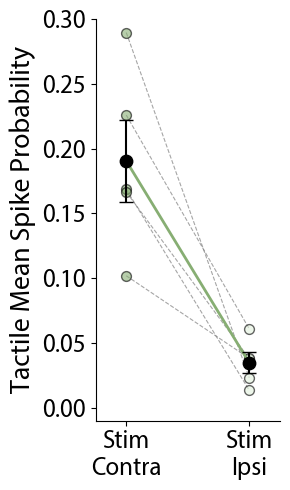

Moyenne et SEM pour 'Cont':
Groupe: Cont, Mean: 0.190425 ± SEM: 0.031605
Groupe: Ipsi, Mean: 0.034682 ± SEM: 0.008026

 contra: n_cluster : 237
ipsi: n_cluster : 123


In [12]:
# Charger les fichiers
WT_tac_cont_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Tac_Wcont_ML2_grouped.xlsx"
df_WT_tac_cont = pd.read_excel(WT_tac_cont_path)

WT_tac_ipsi_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Tac_Wipsi_ML2_grouped.xlsx"
df_WT_tac_ipsi = pd.read_excel(WT_tac_ipsi_path)

# Filtrer pour obtenir uniquement les données où la période est 'Stim'
df_WT_tac_cont_ts = df_WT_tac_cont[df_WT_tac_cont['period'] == 'Stim']
df_WT_tac_ipsi_ts = df_WT_tac_ipsi[df_WT_tac_ipsi['period'] == 'Stim']

# Calculer la moyenne de 'sdf' en groupant par 'directory'
df_WT_tac_cont_grouped = df_WT_tac_cont_ts.groupby('directory')['sdf'].mean().reset_index()
df_WT_tac_ipsi_grouped = df_WT_tac_ipsi_ts.groupby('directory')['sdf'].mean().reset_index()

# Ajouter une colonne pour différencier les groupes
df_WT_tac_cont_grouped['group'] = 'Cont'
df_WT_tac_ipsi_grouped['group'] = 'Ipsi'

# Fusionner les données pour analyse statistique
df_merged = pd.merge(df_WT_tac_cont_grouped, df_WT_tac_ipsi_grouped, on='directory', suffixes=('_cont', '_ipsi'))

# Test de Wilcoxon
n = len(df_merged)
stat, p_value = wilcoxon(df_merged['sdf_cont'], df_merged['sdf_ipsi'])

# Affichage des résultats statistiques
print(f"\nTest de Wilcoxon : Statistique={stat}, p-value={p_value}, n={n}")

# Fusionner pour le tracé
df_combined = pd.concat([df_WT_tac_cont_grouped, df_WT_tac_ipsi_grouped])

# Couleurs
colors = {'Cont': '#87ae73', 'Ipsi': '#e2f0dc'}
border_colors = 'k'

# Création du plot
plt.figure(figsize=(3, 5))

# Ajouter les points individuels pour chaque 'directory'
for group in ['Cont', 'Ipsi']:
    subset = df_combined[df_combined['group'] == group]
    plt.scatter(subset['group'], subset['sdf'], color=colors[group], edgecolor=border_colors, linewidth=1, alpha=0.6, s=50, zorder=6)

# Ajouter les lignes entre les points appariés
for _, row in df_merged.iterrows():
    plt.plot(['Cont', 'Ipsi'], [row['sdf_cont'], row['sdf_ipsi']], color='grey', linestyle='--', linewidth=0.8, alpha=0.7, zorder=0)

# Calcul des moyennes et SEM
mean_sdf = df_combined.groupby('group')['sdf'].mean()
sem_sdf = df_combined.groupby('group')['sdf'].sem()

# Ajouter les moyennes avec barres d'erreur
plt.scatter(mean_sdf.index, mean_sdf.values, color='black', s=80, label='Mean', zorder=10)
plt.errorbar(mean_sdf.index, mean_sdf.values, yerr=sem_sdf.values, fmt='o', color='black', capsize=5, zorder=8)

# Ajouter la ligne reliant les moyennes
plt.plot(mean_sdf.index, mean_sdf.values, color='#87ae73', linestyle='-', linewidth=2, zorder=7)

# Fonction pour ajouter une barre de significativité
def add_Wilcox_sig_bar(x1, x2, y, p_val, height_offset=0.005, fontsize=18):
    if p_val < 0.001:
        significance = "***"
    elif p_val < 0.01:
        significance = "**"
    elif p_val < 0.05:
        significance = "*"
    else:
        return

    plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
    plt.text((x1 + x2) * 0.5, y + height_offset, significance, ha='center', va='bottom', color='black', fontsize=fontsize)

# Ajouter la barre de significativité si p < 0.05
y_max = max(df_combined['sdf']) + 0.02  # Ajustement vertical
if p_value < 0.05:
    add_Wilcox_sig_bar(0, 1, y_max, p_value)

# Paramètres des axes
plt.xlabel("")
plt.ylabel("Tactile Mean Spike Probability")
plt.xticks([0, 1], ['Stim\nContra', 'Stim\nIpsi'])
plt.xlim(-0.25, 1.25)
plt.ylim(-0.01,0.3)


# Suppression des bordures superflues
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Afficher le plot
plt.tight_layout()

# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, '3F_SDF_ML2_TS_tac_cont_vs_ipsi.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, '3F_SDF_ML2_TS_tac_cont_vs_ipsi.svg'), format='svg', dpi=300)


plt.show()

############################    Metrics   ############################ 

# Afficher les résultats
# Afficher les résultats des moyennes et SEM
print("Moyenne et SEM pour 'Cont':")
for group in ['Cont', 'Ipsi']:
    mean = mean_sdf[group]
    sem = sem_sdf[group]
    print(f"Groupe: {group}, Mean: {mean:.6f} ± SEM: {sem:.6f}")

# Calculer nombre cluster par conditions
n_cluster_tac_cont = len(df_WT_tac_cont_ts)
n_cluster_tac_ipsi = len(df_WT_tac_ipsi_ts)

print(f"\n contra: n_cluster : {n_cluster_tac_cont}")
print(f"ipsi: n_cluster : {n_cluster_tac_ipsi}")

### Fig 3.F_BIS - Cluster - ML2 tactile contra vs ipsi sdf for TS


Test de Mann-Whitney : Statistique=26767.0000, p-value=0.0000, n_cont=237, n_ipsi=123


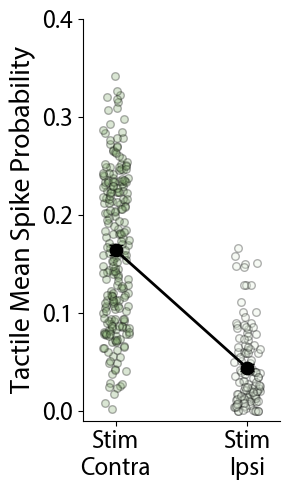

Moyenne et SEM pour chaque groupe :
Cont : 0.164064 ± 0.004997
Ipsi : 0.043917 ± 0.003602

Contra : n_cluster = 237
Ipsi   : n_cluster = 123


In [13]:
# Charger les fichiers
WT_tac_cont_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Tac_Wcont_ML2_grouped.xlsx"
df_WT_tac_cont = pd.read_excel(WT_tac_cont_path)

WT_tac_ipsi_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Tac_Wipsi_ML2_grouped.xlsx"
df_WT_tac_ipsi = pd.read_excel(WT_tac_ipsi_path)

# Filtrer pour obtenir uniquement les données où la période est 'Stim'
df_WT_tac_cont_ts = df_WT_tac_cont[df_WT_tac_cont['period'] == 'Stim']
df_WT_tac_ipsi_ts = df_WT_tac_ipsi[df_WT_tac_ipsi['period'] == 'Stim']

# Regrouper par neurone unique et période pour s'assurer d'une entrée unique
df_WT_tac_cont_ts_cluster = df_WT_tac_cont_ts.groupby(['directory', 'file_name', 'neuron_id', 'period'], as_index=False, observed=True).mean(numeric_only=True)
df_WT_tac_ipsi_ts_cluster = df_WT_tac_ipsi_ts.groupby(['directory', 'file_name', 'neuron_id', 'period'], as_index=False, observed=True).mean(numeric_only=True)

# Ajouter une colonne pour différencier les groupes
df_WT_tac_cont_ts_cluster['group'] = 'Cont'
df_WT_tac_ipsi_ts_cluster['group'] = 'Ipsi'


# Mann-Whitney test sur les deux groupes
sdf_tac_cont = df_WT_tac_cont_ts_cluster['sdf']
sdf_tac_ipsi = df_WT_tac_ipsi_ts_cluster['sdf']

stat_mannwhit, p_value_mannwhit = mannwhitneyu(sdf_tac_cont, sdf_tac_ipsi, alternative='two-sided')

print(f"\nTest de Mann-Whitney : Statistique={stat_mannwhit:.4f}, p-value={p_value_mannwhit:.4f}, n_cont={len(sdf_tac_cont)}, n_ipsi={len(sdf_tac_ipsi)}")


# Fusionner pour le tracé
df_combined_cluster = pd.concat([df_WT_tac_cont_ts_cluster, df_WT_tac_ipsi_ts_cluster])

# Couleurs
colors = {'Cont': '#87ae73', 'Ipsi': '#e2f0dc'}

border_colors = 'k'

# Création du plot
plt.figure(figsize=(3, 5))

# Ajouter les points individuels avec léger jitter
group_mapping = {'Cont': 0, 'Ipsi': 1}
for group in ['Cont', 'Ipsi']:
    subset = df_combined_cluster[df_combined_cluster['group'] == group]
    x_vals = np.ones(len(subset)) * group_mapping[group]
    x_vals += np.random.uniform(-0.1, 0.1, size=len(subset))  # jitter horizontal
    plt.scatter(x_vals, subset['sdf'], color=colors[group], edgecolor=border_colors, linewidth=1, alpha=0.3, s=30, zorder=6)

# Calcul des moyennes et SEM
mean_sdf_cluster = df_combined_cluster.groupby('group')['sdf'].mean()
sem_sdf_cluster = df_combined_cluster.groupby('group')['sdf'].sem()


# Obtenir les positions numériques dans le même ordre que mean_sdf.index
x_pos = [group_mapping[group] for group in mean_sdf_cluster.index]

# Ajouter les moyennes avec barres d'erreur
plt.scatter(x_pos, mean_sdf_cluster.values, color='black', s=80, label='Mean', zorder=10)
plt.errorbar(x_pos, mean_sdf_cluster.values, yerr=sem_sdf_cluster.values, fmt='o', color='black', capsize=5, zorder=8)

# Ajouter la ligne reliant les moyennes
plt.plot(x_pos, mean_sdf_cluster.values, color='k', linestyle='-', linewidth=2, zorder=7)


# # Ajouter la barre de significativité
# def add_MannWhitney_sig_bar(x1, x2, y, p_value_mannwhit, height_offset=0.005, fontsize=18):
#     if p_value_mannwhit < 0.001:
#         significance = "***"
#     elif p_value_mannwhit < 0.01:
#         significance = "**"
#     elif p_value_mannwhit < 0.05:
#         significance = "*"
#     else:
#         return
#     plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
#     plt.text((x1 + x2) * 0.5, y + height_offset, significance, ha='center', va='bottom', color='black', fontsize=fontsize)

# # Ajouter si p < 0.05
# y_max = max(df_combined_cluster['sdf']) + 0.02
# if p_value_mannwhit < 0.05:
#     add_MannWhitney_sig_bar(0, 1, y_max, p_value_mannwhit)

# Mise en forme
plt.xlabel("")
plt.ylabel("Tactile Mean Spike Probability")
plt.xticks([0, 1], ['Stim\nContra', 'Stim\nIpsi'])
plt.xlim(-0.25, 1.25)
plt.ylim(-0.01,0.4)


# Nettoyer les bords
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, '3F_BIS_SDF_ML2_TS_tac_cont_vs_ipsi_cluster.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, '3F_BIS_SDF_ML2_TS_tac_cont_vs_ipsi_cluster.svg'), format='svg', dpi=300)


plt.show()


############################    Metrics   ############################ 
print("Moyenne et SEM pour chaque groupe :")
for group in ['Cont', 'Ipsi']:
    mean = mean_sdf_cluster[group]
    sem = sem_sdf_cluster[group]
    print(f"{group} : {mean:.6f} ± {sem:.6f}")

# Nombre de clusters
n_cluster_tac_cont = len(df_WT_tac_cont_ts)
n_cluster_tac_ipsi = len(df_WT_tac_ipsi_ts)
print(f"\nContra : n_cluster = {n_cluster_tac_cont}")
print(f"Ipsi   : n_cluster = {n_cluster_tac_ipsi}")


#

### Fig 3.G - ML2 vs WT Tactile response rate contra

n (WT_Cont) = 10
n (ML2_cont) = 5
Wilcoxon test result: statistic = 25.0000, p-value = 1.0000


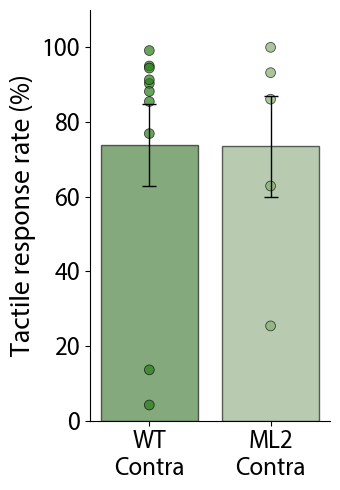


WT_tac_cont : mean = 73.86 ± 11.01
ML2_tac_cont : mean = 73.51 ± 13.56

 contra: n_cluster : 566
ipsi: n_cluster : 237


In [ ]:
# Charger les fichiers
WT_tac_cont_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/cluster_response_rate/Tac_Wcont_WT_resp_rate.xlsx"
df_WT_tac_cont = pd.read_excel(WT_tac_cont_path)

ML2_tac_cont_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/cluster_response_rate/Tac_Wcont_ML2_resp_rate.xlsx"
df_ML2_tac_cont = pd.read_excel(ML2_tac_cont_path)

# Calcul du pourcentage de '1' dans la colonne 'response' pour chaque combinaison de 'directory' et 'file_name'
def calculate_response_percentage(df):
    # Grouper par 'directory' et 'file_name' et calculer le pourcentage de 1 dans la colonne 'response'
    response_percentage = df.groupby(['directory', 'file_name'])['response'].agg(
        lambda x: (x.sum() / len(x)) * 100
    ).reset_index()
    
    # Renommer la colonne pour plus de clarté
    response_percentage.rename(columns={'response': 'response_percentage'}, inplace=True)
    
    return response_percentage

# Appliquer la fonction sur chaque DataFrame
response_percentage_WT_tac_cont = calculate_response_percentage(df_WT_tac_cont)
response_percentage_ML2_tac_cont = calculate_response_percentage(df_ML2_tac_cont)


# Calculer la moyenne des pourcentages de réponse pour chaque 'directory' commun
average_response_percentage_WT_cont = response_percentage_WT_tac_cont.groupby('directory')['response_percentage'].mean().reset_index()
average_response_percentage_ML2_cont = response_percentage_ML2_tac_cont.groupby('directory')['response_percentage'].mean().reset_index()

# Créer une nouvelle colonne 'group' pour identifier chaque DataFrame
average_response_percentage_WT_cont['group'] = 'WT_Cont'
average_response_percentage_ML2_cont['group'] = 'ML2_cont'

# Fusionner les deux DataFrames en un seul
combined_df_WT_ML2 = pd.concat([average_response_percentage_WT_cont, average_response_percentage_ML2_cont])

# Calculer la SEM pour chaque groupe
combined_df_WT_ML2['sem'] = combined_df_WT_ML2.groupby('group')['response_percentage'].transform(sem)

# Calculer n (le nombre d'observations pour chaque groupe)
n_WT_cont = len(average_response_percentage_WT_cont)
n_ML2_cont = len(average_response_percentage_ML2_cont)


# Effectuer le test de Wilcoxon pour comparer les groupes 'Cont' et 'Ipsi'
stat, p_value = mannwhitneyu(average_response_percentage_WT_cont['response_percentage'], 
                             average_response_percentage_ML2_cont['response_percentage'], 
                             alternative='two-sided')


# Afficher les résultats avec n et p-value
print(f"n (WT_Cont) = {n_WT_cont}")
print(f"n (ML2_cont) = {n_ML2_cont}")
print(f"Wilcoxon test result: statistic = {stat:.4f}, p-value = {p_value:.4f}")


# Couleurs
colors = {'WT_Cont': '#2a7e19', 'ML2_cont': '#87ae73'}
border_colors = 'k'

# Plot
plt.figure(figsize=(3.5, 5))

# Créer un barplot par groupe (moyenne des response_percentage par group) avec des couleurs personnalisées
sns.barplot(x='group', y='response_percentage', data=combined_df_WT_ML2, 
            errorbar=None,  # Désactive les barres d'erreur
            hue='group', palette=colors, capsize=0.1, err_kws={'linewidth': 1}, alpha=0.6, edgecolor=border_colors)

# Ajouter des points de scatter pour chaque directory avec des couleurs personnalisées pour chaque groupe
sns.scatterplot(x='group', y='response_percentage', hue='group', data=combined_df_WT_ML2, 
                palette=colors, s=50, legend=None, marker='o', edgecolor=border_colors, alpha=0.7)


# Ajouter les barres d'erreur (SEM)
for i, group in enumerate(combined_df_WT_ML2['group'].unique()):
    group_data = combined_df_WT_ML2[combined_df_WT_ML2['group'] == group]
    plt.errorbar(x=[i], y=group_data['response_percentage'].mean(), yerr=group_data['sem'].mean(),
                 fmt='none', color=border_colors, capsize=5, elinewidth=1)


# Fonction pour ajouter une barre de significativité
def add_mannwhitneyu_sig_bar(x1, x2, y, p_val, height_offset=1.2, fontsize=18):
    if p_val < 0.001:
        significance = "***"
    elif p_val < 0.01:
        significance = "**"
    elif p_val < 0.05:
        significance = "*"
    else:
        return

    plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
    plt.text((x1 + x2) * 0.5, y , significance, ha='center', va='bottom', color='black', fontsize=fontsize)

# Ajouter la barre de significativité si p < 0.05
y_max = max(combined_df_WT_ML2['response_percentage']) + 0.02  # Ajustement vertical
if p_value < 0.05:
    add_mannwhitneyu_sig_bar(0, 1, y_max + 3, p_value)


# Ajouter le titre et les labels
plt.xlabel('')
plt.ylabel('Tactile response rate (%)')
xtick_labels = ['WT\nContra', 'ML2\nContra']  # Les nouveaux labels pour les xticks
plt.xticks(ticks=[0, 1], labels=xtick_labels)
plt.ylim(0, 110)


# Suppression des bordures superflues
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Afficher le graphique
plt.tight_layout()

# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, '3G_WT_vs_ML2_tac_cont_resp_rate.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, '3G_WT_vs_ML2_tac_cont_resp_rate.svg'), format='svg', dpi=300)

plt.show()


############################    Metrics   ############################ 

# Calculer la moyenne et SEM pour 'WT_tac_cont'
mean_WT_cont = average_response_percentage_WT_cont['response_percentage'].mean()
sem_WT_cont = sem(average_response_percentage_WT_cont['response_percentage'])

# Calculer la moyenne et SEM pour 'ML2_tac_cont'
mean_ML2_cont = average_response_percentage_ML2_cont['response_percentage'].mean()
sem_ML2_cont = sem(average_response_percentage_ML2_cont['response_percentage'])

# Afficher les résultats
print(f"\nWT_tac_cont : mean = {mean_WT_cont:.2f} ± {sem_WT_cont:.2f}")
print(f"ML2_tac_cont : mean = {mean_ML2_cont:.2f} ± {sem_ML2_cont:.2f}")

# Calculer nombre cluster par conditions
n_cluster_tac_cont = len(df_WT_tac_cont)
n_cluster_tac_ipsi = len(df_ML2_tac_cont)

print(f"\n contra: n_cluster : {n_cluster_tac_cont}")
print(f"ipsi: n_cluster : {n_cluster_tac_ipsi}")


### Fig 3.G_BIS - Cluster/Contingence - ML2 vs WT Tactile response rate contra

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



Table de contingence (nombre d'occurences de 0 et 1 par groupe) :
response        1    0
WT_Tac_Cont   330  236
ML2_Tac_Cont  149   88

Test chi2 de contingence entre groupes : chi2 = 1.263, p = 0.2611, dof = 1
=> Pas de différence significative entre groupes

Tests post-hoc (test exact de Fisher) avec correction de Bonferroni :
WT_Tac_Cont vs ML2_Tac_Cont : p = 0.2378, p corrigé = 0.2378 -> non significatif


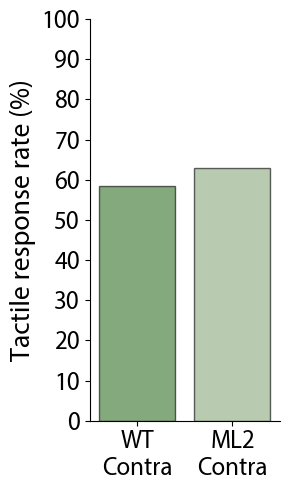


Métriques des réponses par groupe :
WT_Tac_Cont : Moyenne = 0.58, Nombre de clusters = 566, Pourcentage de réponse = 58.3%
ML2_Tac_Cont : Moyenne = 0.63, Nombre de clusters = 237, Pourcentage de réponse = 62.9%


In [ ]:
# Chemins fichiers
file_paths = {
    "WT_Tac_Cont": "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/cluster_response_rate/Tac_Wcont_WT_resp_rate.xlsx",
    "ML2_Tac_Cont": "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/cluster_response_rate/Tac_Wcont_ML2_resp_rate.xlsx"
}


# Chargement des données
dfs = {}
for key, path in file_paths.items():
    if os.path.exists(path):
        dfs[key] = pd.read_excel(path)
    else:
        print(f"⚠️ Fichier non trouvé : {path}")


# Calcul pourcentages réponse/non-réponse
group_counts = {}
for key, df in dfs.items():
    counts = df['response'].value_counts(normalize=True) * 100
    group_counts[key] = {
        'No Response (0)': counts.get(0, 0),
        'Response (1)': counts.get(1, 0)
    }


# DataFrame pour plot
contingency_df = pd.DataFrame(group_counts).T.reset_index().rename(columns={'index': 'group'})
contingency_melted = contingency_df.melt(id_vars='group', var_name='Response Type', value_name='Percentage')
contingency_melted_response_only = contingency_melted[contingency_melted['Response Type'] == 'Response (1)']


# Couleurs personnalisées
response_colors = {
    'WT_Tac_Cont': '#2a7e19',
    'ML2_Tac_Cont': '#87ae73'
}

border_colors = 'k'

# Plot barplot
plt.figure(figsize=(3, 5))
ax = sns.barplot(
    data=contingency_melted_response_only,
    x='group', y='Percentage', hue='group',
    palette=response_colors,
    edgecolor=border_colors,
    alpha=0.6, errorbar=None
)

# Table de contingence brute
contingency_table = pd.DataFrame({
    key: dfs[key]['response'].value_counts() for key in dfs.keys()
}).fillna(0).astype(int).T

print("\nTable de contingence (nombre d'occurences de 0 et 1 par groupe) :")
print(contingency_table)

# Test global chi2
chi2, p, dof, expected = chi2_contingency(contingency_table.values)
print(f"\nTest chi2 de contingence entre groupes : chi2 = {chi2:.3f}, p = {p:.4g}, dof = {dof}")
if p < 0.05:
    print("=> Différence significative entre groupes")
else:
    print("=> Pas de différence significative entre groupes")

# Tests post-hoc (Fisher exact test)
groups = contingency_table.index.tolist()
results = []

for g1, g2 in combinations(groups, 2):
    table = contingency_table.loc[[g1, g2], [0, 1]].values
    oddsratio, pvalue = fisher_exact(table)
    results.append({'Group1': g1, 'Group2': g2, 'pvalue': pvalue})

# Correction Bonferroni
num_tests = len(results)
for res in results:
    res['pvalue_corrected'] = min(res['pvalue'] * num_tests, 1.0)

print("\nTests post-hoc (test exact de Fisher) avec correction de Bonferroni :")
for res in results:
    signif = "SIGNIFICATIF" if res['pvalue_corrected'] < 0.05 else "non significatif"
    print(f"{res['Group1']} vs {res['Group2']} : p = {res['pvalue']:.4g}, p corrigé = {res['pvalue_corrected']:.4g} -> {signif}")


# # Annoter les significativités sur le plot
# def add_contingence_sig_bar(ax, x1, x2, y, p_val, height_offset=1, fontsize=18):
#     significance = ""
#     if p_val < 0.001:
#         significance = "***"
#     elif p_val < 0.01:
#         significance = "**"
#     elif p_val < 0.05:
#         significance = "*"
#     if significance:
#         ax.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
#         ax.text((x1 + x2) * 0.5, y - 0.05 , significance,
#                 ha='center', va='bottom', color='black', fontsize=fontsize)

# positions = {g: i for i, g in enumerate(contingency_df['group'])}
# y_offset = contingency_melted_response_only['Percentage'].max() + 5
# spacing_between_bars = 0.8

# for res in results:
#     if res['pvalue_corrected'] < 0.05:
#         x1 = positions[res['Group1']]
#         x2 = positions[res['Group2']]
#         add_contingence_sig_bar(ax, x1, x2, y_offset, res['pvalue_corrected'])
#         y_offset += spacing_between_bars

# Labels
plt.xlabel('')
plt.ylabel('Tactile response rate (%)')
plt.xticks(ticks=[0, 1], labels=['WT\nContra', 'ML2\nContra'])
plt.yticks(range(0, 101, 10))
plt.ylim(0, 100)

# Suppression bordures inutiles
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.legend().remove()
plt.tight_layout()

# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, '3G_BIS_WT_vs_ML2_tac_cont_resp_rate_cluster_contingence.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, '3G_BIS_WT_vs_ML2_tac_cont_resp_rate_cluster_contingence.svg'), format='svg', dpi=300)


plt.show()


############################ Metrics ############################

print("\nMétriques des réponses par groupe :")
for key, df in dfs.items():
    mean_response = df['response'].mean()  # moyenne des 0 et 1 = taux de réponse en fraction
    n_clusters = len(df)
    response_percentage = mean_response * 100
    print(f"{key} : Moyenne = {mean_response:.2f}, Nombre de clusters = {n_clusters}, Pourcentage de réponse = {response_percentage:.1f}%")



#

### Fig 3.H - ML2 vs WT Tactile SDF contra

n (WT_Cont) = 10
n (ML2_Cont) = 5
Wilcoxon test result: statistic = 23.0000, p-value = 0.8591


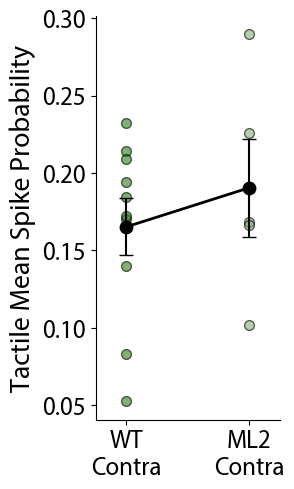

Moyenne et SEM pour:
Groupe: WT_Cont, Mean: 0.165173 ± SEM: 0.018324
Groupe: ML2_Cont, Mean: 0.190425 ± SEM: 0.031605

WT_contra: n_cluster : 566
ML2_contra: n_cluster : 237


In [ ]:
# Charger les fichiers
WT_tac_cont_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Tac_Wcont_WT_grouped.xlsx"
df_WT_tac_cont = pd.read_excel(WT_tac_cont_path)

ML2_tac_cont_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Tac_Wcont_ML2_grouped.xlsx"
df_ML2_tac_cont = pd.read_excel(ML2_tac_cont_path)

# Filtrer pour obtenir uniquement les données où la période est 'Stim'
df_WT_tac_cont_ts = df_WT_tac_cont[df_WT_tac_cont['period'] == 'Stim']
df_ML2_tac_cont_ts = df_ML2_tac_cont[df_ML2_tac_cont['period'] == 'Stim']

# Calculer la moyenne de 'sdf' en groupant par 'directory'
df_WT_tac_cont_grouped = df_WT_tac_cont_ts.groupby('directory')['sdf'].mean().reset_index()
df_ML2_tac_cont_grouped = df_ML2_tac_cont_ts.groupby('directory')['sdf'].mean().reset_index()

# Ajouter une colonne pour différencier les groupes
df_WT_tac_cont_grouped['group'] = 'WT_Cont'
df_ML2_tac_cont_grouped['group'] = 'ML2_Cont'

n_WT_cont = len(df_WT_tac_cont_grouped)
n_ML2_cont = len(df_ML2_tac_cont_grouped)

# Effectuer le test de Wilcoxon pour comparer les groupes 'Cont' et 'Ipsi'
stat, p_value = mannwhitneyu(df_WT_tac_cont_grouped['sdf'], 
                             df_ML2_tac_cont_grouped['sdf'], 
                             alternative='two-sided')


# Afficher les résultats avec n et p-value
print(f"n (WT_Cont) = {n_WT_cont}")
print(f"n (ML2_Cont) = {n_ML2_cont}")
print(f"Wilcoxon test result: statistic = {stat:.4f}, p-value = {p_value:.4f}")


# Fusionner pour le tracé
combined_df_WT_ML2_sdf = pd.concat([df_WT_tac_cont_grouped, df_ML2_tac_cont_grouped])

# Couleurs
colors = {'WT_Cont': '#2a7e19', 'ML2_Cont': '#87ae73'}
border_colors = 'k'

# Création du plot
plt.figure(figsize=(3, 5))

# Ajouter les points individuels pour chaque 'directory'
for group in ['WT_Cont', 'ML2_Cont']:
    subset = combined_df_WT_ML2_sdf[combined_df_WT_ML2_sdf['group'] == group]
    plt.scatter(subset['group'], subset['sdf'], color=colors[group], edgecolor=border_colors, linewidth=1, alpha=0.6, s=50, zorder=6)


# Calcul des moyennes et SEM
mean_sdf = combined_df_WT_ML2_sdf.groupby('group')['sdf'].mean()
sem_sdf = combined_df_WT_ML2_sdf.groupby('group')['sdf'].sem()

# Ajouter les moyennes avec barres d'erreur
plt.scatter(mean_sdf.index, mean_sdf.values, color='black', s=80, label='Mean', zorder=10)
plt.errorbar(mean_sdf.index, mean_sdf.values, yerr=sem_sdf.values, fmt='o', color='black', capsize=5, zorder=8)

# Ajouter la ligne reliant les moyennes
plt.plot(mean_sdf.index, mean_sdf.values, color='k', linestyle='-', linewidth=2, zorder=7)

# Fonction pour ajouter une barre de significativité
def add_mannwhitneyu_sig_bar(x1, x2, y, p_val, height_offset=1.2, fontsize=18):
    if p_val < 0.001:
        significance = "***"
    elif p_val < 0.01:
        significance = "**"
    elif p_val < 0.05:
        significance = "*"
    else:
        return

    plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
    plt.text((x1 + x2) * 0.5, y , significance, ha='center', va='bottom', color='black', fontsize=fontsize)

# Ajouter la barre de significativité si p < 0.05
y_max = max(combined_df_WT_ML2_sdf['sdf']) + 0.02  # Ajustement vertical
if p_value < 0.05:
    add_mannwhitneyu_sig_bar(0, 1, y_max + 3, p_value)

# Paramètres des axes
plt.xlabel("")
plt.ylabel("Tactile Mean Spike Probability")
plt.xticks([0, 1], ['WT\nContra', 'ML2\nContra'])
plt.xlim(-0.25, 1.25)

# Suppression des bordures superflues
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Afficher le plot
plt.tight_layout()

# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, '3H_SDF_ML2_vs_WT_TS_tac_cont.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, '3H_SDF_ML2_vs_WT_TS_tac_cont.svg'), format='svg', dpi=300)


plt.show()

############################    Metrics   ############################ 

# Afficher les résultats
# Afficher les résultats des moyennes et SEM
print("Moyenne et SEM pour:")
for group in ['WT_Cont', 'ML2_Cont']:
    mean = mean_sdf[group]
    sem = sem_sdf[group]
    print(f"Groupe: {group}, Mean: {mean:.6f} ± SEM: {sem:.6f}")

# Calculer nombre cluster par conditions
n_cluster_WT_tac_cont = len(df_WT_tac_cont_ts)
n_cluster_ML2_tac_cont = len(df_ML2_tac_cont_ts)

print(f"\nWT_contra: n_cluster : {n_cluster_WT_tac_cont}")
print(f"ML2_contra: n_cluster : {n_cluster_ML2_tac_cont}")

### Fig 3.H_BIS - Cluster - ML2 vs WT Tactile SDF contra


Test de Mann-Whitney : Statistique=53520.0000, p-value=0.0000, n_WT=566, n_ML2=237


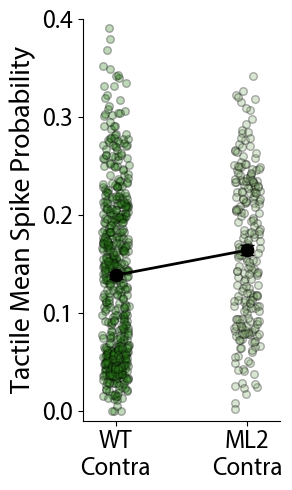

Moyenne et SEM pour:
Groupe: WT_Cont, Mean: 0.1385 ± SEM: 0.0036
Groupe: ML2_Cont, Mean: 0.1641 ± SEM: 0.0050

WT_contra: n_cluster : 566
ML2_contra: n_cluster : 237
Le fichier a été sauvegardé sous : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/plot_for_fig/Plot_svg_illustrator\Plot_Fig_3_WT_vs_ML2_Tac\df_SDF_WT_vs_ML2_Tactile_Wcontra_cluster.xlsx

Voir Graphpad pour Anova


In [14]:
# Charger les fichiers
WT_tac_cont_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Tac_Wcont_WT_grouped.xlsx"
df_WT_tac_cont = pd.read_excel(WT_tac_cont_path)

ML2_tac_cont_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Tac_Wcont_ML2_grouped.xlsx"
df_ML2_tac_cont = pd.read_excel(ML2_tac_cont_path)

# Filtrer pour obtenir uniquement les données où la période est 'Stim'
df_WT_tac_cont_ts = df_WT_tac_cont[df_WT_tac_cont['period'] == 'Stim']
df_ML2_tac_cont_ts = df_ML2_tac_cont[df_ML2_tac_cont['period'] == 'Stim']


# Regrouper par neurone unique et période pour s'assurer d'une entrée unique
df_WT_tac_cont_ts_cluster = df_WT_tac_cont_ts.groupby(['directory', 'file_name', 'neuron_id', 'period'], as_index=False, observed=True).mean(numeric_only=True)
df_ML2_tac_cont_ts_cluster = df_ML2_tac_cont_ts.groupby(['directory', 'file_name', 'neuron_id', 'period'], as_index=False, observed=True).mean(numeric_only=True)

# Ajouter une colonne pour différencier les groupes
df_WT_tac_cont_ts_cluster['group'] = 'WT_Cont'
df_ML2_tac_cont_ts_cluster['group'] = 'ML2_Cont'


# Mann-Whitney test sur les deux groupes
sdf_WT_tac_cont = df_WT_tac_cont_ts_cluster['sdf']
sdf_ML2_tac_cont = df_ML2_tac_cont_ts_cluster['sdf']

stat_mannwhit, p_value_mannwhit = mannwhitneyu(sdf_WT_tac_cont, sdf_ML2_tac_cont, alternative='two-sided')

print(f"\nTest de Mann-Whitney : Statistique={stat_mannwhit:.4f}, p-value={p_value_mannwhit:.4f}, n_WT={len(sdf_WT_tac_cont)}, n_ML2={len(sdf_ML2_tac_cont)}")


# Fusionner pour le tracé
combined_df_WT_ML2_sdf = pd.concat([df_WT_tac_cont_ts_cluster, df_ML2_tac_cont_ts_cluster])

# Couleurs
colors = {'WT_Cont': '#2a7e19', 'ML2_Cont': '#87ae73'}
border_colors = 'k'

# Création du plot
plt.figure(figsize=(3, 5))

# #Ajouter les points individuels de chaque clusters
# for group in ['WT_Cont', 'ML2_Cont']:
#     subset = combined_df_WT_ML2_sdf[combined_df_WT_ML2_sdf['group'] == group]
#     plt.scatter(subset['group'], subset['sdf'], color=colors[group], edgecolor=border_colors, linewidth=1, alpha=0.6, s=50, zorder=6)

# Ajouter les points individuels avec léger jitter
group_mapping = {'WT_Cont': 0, 'ML2_Cont': 1}
for group in ['WT_Cont', 'ML2_Cont']:
    subset = combined_df_WT_ML2_sdf[combined_df_WT_ML2_sdf['group'] == group]
    x_vals = np.ones(len(subset)) * group_mapping[group]
    x_vals += np.random.uniform(-0.1, 0.1, size=len(subset))  # jitter horizontal
    plt.scatter(x_vals, subset['sdf'], color=colors[group], edgecolor=border_colors, linewidth=1, alpha=0.3, s=30, zorder=6)


# Calcul des moyennes et SEM
mean_sdf = combined_df_WT_ML2_sdf.groupby('group')['sdf'].mean()
sem_sdf = combined_df_WT_ML2_sdf.groupby('group')['sdf'].sem()


# Obtenir les positions numériques dans le même ordre que mean_sdf.index
x_pos = [group_mapping[group] for group in mean_sdf.index]

# Ajouter les moyennes avec barres d'erreur
plt.scatter(x_pos, mean_sdf.values, color='black', s=80, label='Mean', zorder=10)
plt.errorbar(x_pos, mean_sdf.values, yerr=sem_sdf.values, fmt='o', color='black', capsize=5, zorder=8)

# Ajouter la ligne reliant les moyennes
plt.plot(x_pos, mean_sdf.values, color='k', linestyle='-', linewidth=2, zorder=7)


# # Fonction pour ajouter une barre de significativité
# def add_mannwhitneyu_sig_bar(x1, x2, y, p_val, height_offset=0.01, fontsize=18):
#     if p_val < 0.001:
#         significance = "***"
#     elif p_val < 0.01:
#         significance = "**"
#     elif p_val < 0.05:
#         significance = "*"
#     else:
#         return

#     plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
#     plt.text((x1 + x2) * 0.5, y , significance, ha='center', va='bottom', color='black', fontsize=fontsize)

# # Ajouter la barre de significativité si p < 0.05
# y_max = max(combined_df_WT_ML2_sdf['sdf']) + 0.02  # Ajustement vertical
# if p_value_mannwhit < 0.05:
#     add_mannwhitneyu_sig_bar(0, 1, y_max, p_value_mannwhit)

# Paramètres des axes
plt.xlabel("")
plt.ylabel("Tactile Mean Spike Probability")
plt.xticks([0, 1], ['WT\nContra', 'ML2\nContra'])
plt.xlim(-0.25, 1.25)
plt.ylim(-0.01,0.4)


# Suppression des bordures superflues
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Afficher le plot
plt.tight_layout()

# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, '3H_BIS_SDF_ML2_vs_WT_TS_tac_cont_cluster.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, '3H_BIS_SDF_ML2_vs_WT_TS_tac_cont_cluster.svg'), format='svg', dpi=300)


plt.show()

############################    Metrics   ############################ 

# Afficher les résultats des moyennes et SEM
print("Moyenne et SEM pour:")
for group in ['WT_Cont', 'ML2_Cont']:
    mean = mean_sdf[group]
    sem = sem_sdf[group]
    print(f"Groupe: {group}, Mean: {mean:.4f} ± SEM: {sem:.4f}")

# Calculer nombre cluster par conditions
n_cluster_WT_tac_cont = len(df_WT_tac_cont_ts)
n_cluster_ML2_tac_cont = len(df_ML2_tac_cont_ts)

print(f"\nWT_contra: n_cluster : {n_cluster_WT_tac_cont}")
print(f"ML2_contra: n_cluster : {n_cluster_ML2_tac_cont}")




file_name = "df_SDF_WT_vs_ML2_Tactile_Wcontra_cluster.xlsx"

anova_path = os.path.join(saving_dir,file_name)

# Sauvegarder le DataFrame `df_combined` dans le fichier Excel
combined_df_WT_ML2_sdf.to_excel(anova_path , index=False)

print(f"Le fichier a été sauvegardé sous : {anova_path}")


print (f'\nVoir Graphpad pour Anova')


### Fig 3 - Cluster - ML2 vs WT Tactile SDF Ipsi

n (WT_Cont) = 9
n (ML2_Cont) = 5
Wilcoxon test result: statistic = 29.0000, p-value = 0.4376


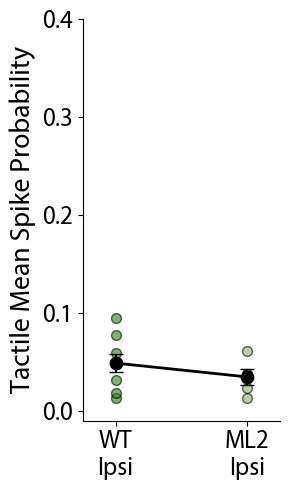

Moyenne et SEM pour:
Groupe: WT_Cont, Mean: 0.048768 ± SEM: 0.008794
Groupe: ML2_Cont, Mean: 0.034682 ± SEM: 0.008026

WT_contra: n_cluster : 401
ML2_contra: n_cluster : 123


In [15]:
# Charger les fichiers
WT_tac_cont_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Tac_Wipsi_WT_grouped.xlsx"
df_WT_tac_cont = pd.read_excel(WT_tac_cont_path)

ML2_tac_cont_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Tac_Wipsi_ML2_grouped.xlsx"
df_ML2_tac_cont = pd.read_excel(ML2_tac_cont_path)

# Filtrer pour obtenir uniquement les données où la période est 'Stim'
df_WT_tac_cont_ts = df_WT_tac_cont[df_WT_tac_cont['period'] == 'Stim']
df_ML2_tac_cont_ts = df_ML2_tac_cont[df_ML2_tac_cont['period'] == 'Stim']

# Calculer la moyenne de 'sdf' en groupant par 'directory'
df_WT_tac_cont_grouped = df_WT_tac_cont_ts.groupby('directory')['sdf'].mean().reset_index()
df_ML2_tac_cont_grouped = df_ML2_tac_cont_ts.groupby('directory')['sdf'].mean().reset_index()

# Ajouter une colonne pour différencier les groupes
df_WT_tac_cont_grouped['group'] = 'WT_Cont'
df_ML2_tac_cont_grouped['group'] = 'ML2_Cont'

n_WT_cont = len(df_WT_tac_cont_grouped)
n_ML2_cont = len(df_ML2_tac_cont_grouped)

# Effectuer le test de Wilcoxon pour comparer les groupes 'Cont' et 'Ipsi'
stat, p_value = mannwhitneyu(df_WT_tac_cont_grouped['sdf'], 
                             df_ML2_tac_cont_grouped['sdf'], 
                             alternative='two-sided')


# Afficher les résultats avec n et p-value
print(f"n (WT_Cont) = {n_WT_cont}")
print(f"n (ML2_Cont) = {n_ML2_cont}")
print(f"Wilcoxon test result: statistic = {stat:.4f}, p-value = {p_value:.4f}")


# Fusionner pour le tracé
combined_df_WT_ML2_sdf = pd.concat([df_WT_tac_cont_grouped, df_ML2_tac_cont_grouped])

# Couleurs
colors = {'WT_Cont': '#2a7e19', 'ML2_Cont': '#87ae73'}
border_colors = 'k'

# Création du plot
plt.figure(figsize=(3, 5))

# Ajouter les points individuels pour chaque 'directory'
for group in ['WT_Cont', 'ML2_Cont']:
    subset = combined_df_WT_ML2_sdf[combined_df_WT_ML2_sdf['group'] == group]
    plt.scatter(subset['group'], subset['sdf'], color=colors[group], edgecolor=border_colors, linewidth=1, alpha=0.6, s=50, zorder=6)


# Calcul des moyennes et SEM
mean_sdf = combined_df_WT_ML2_sdf.groupby('group')['sdf'].mean()
sem_sdf = combined_df_WT_ML2_sdf.groupby('group')['sdf'].sem()

# Ajouter les moyennes avec barres d'erreur
plt.scatter(mean_sdf.index, mean_sdf.values, color='black', s=80, label='Mean', zorder=10)
plt.errorbar(mean_sdf.index, mean_sdf.values, yerr=sem_sdf.values, fmt='o', color='black', capsize=5, zorder=8)

# Ajouter la ligne reliant les moyennes
plt.plot(mean_sdf.index, mean_sdf.values, color='k', linestyle='-', linewidth=2, zorder=7)

# Fonction pour ajouter une barre de significativité
def add_mannwhitneyu_sig_bar(x1, x2, y, p_val, height_offset=1.2, fontsize=18):
    if p_val < 0.001:
        significance = "***"
    elif p_val < 0.01:
        significance = "**"
    elif p_val < 0.05:
        significance = "*"
    else:
        return

    plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
    plt.text((x1 + x2) * 0.5, y , significance, ha='center', va='bottom', color='black', fontsize=fontsize)

# Ajouter la barre de significativité si p < 0.05
y_max = max(combined_df_WT_ML2_sdf['sdf']) + 0.02  # Ajustement vertical
if p_value < 0.05:
    add_mannwhitneyu_sig_bar(0, 1, y_max + 3, p_value)

# Paramètres des axes
plt.xlabel("")
plt.ylabel("Tactile Mean Spike Probability")
plt.xticks([0, 1], ['WT\nIpsi', 'ML2\nIpsi'])
plt.xlim(-0.25, 1.25)
plt.ylim(-0.01,0.4)


# Suppression des bordures superflues
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Afficher le plot
plt.tight_layout()

# # Sauvegarder la figure
# plt.savefig(os.path.join(saving_dir, '3H_SDF_ML2_vs_WT_TS_tac_cont.png'), format='png', dpi=300)
# plt.savefig(os.path.join(saving_dir, '3H_SDF_ML2_vs_WT_TS_tac_cont.svg'), format='svg', dpi=300)


plt.show()

############################    Metrics   ############################ 

# Afficher les résultats
# Afficher les résultats des moyennes et SEM
print("Moyenne et SEM pour:")
for group in ['WT_Cont', 'ML2_Cont']:
    mean = mean_sdf[group]
    sem = sem_sdf[group]
    print(f"Groupe: {group}, Mean: {mean:.6f} ± SEM: {sem:.6f}")

# Calculer nombre cluster par conditions
n_cluster_WT_tac_cont = len(df_WT_tac_cont_ts)
n_cluster_ML2_tac_cont = len(df_ML2_tac_cont_ts)

print(f"\nWT_contra: n_cluster : {n_cluster_WT_tac_cont}")
print(f"ML2_contra: n_cluster : {n_cluster_ML2_tac_cont}")

#

#